# Mercari(일본 중고거래 플랫폼) 가격 예측 프로젝트

## 프로젝트 흐름  
1. 환경 설정 및 데이터 로드
2. 데이터 전처리 (카테고리 분리, 결측치 처리)
3. 텍스트 특징 추출 (NLP_자연어 처리)
4. 새로운 피처 생성
5. 모델 학습
6. 가격 예측 & 제출  

### 1. 환경설정 및 데이터 로드

In [137]:
pip install pandas numpy scikit-learn lightgbm nltk scipy

Note: you may need to restart the kernel to use updated packages.


In [138]:
# 1. 환경설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. 데이터 로드
train = pd.read_csv('train.tsv', sep='\t')
test  = pd.read_csv('test.tsv',  sep='\t')

print(train.shape)
print(train.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\berga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\berga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\berga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(1482535, 8)
   train_id                                 name  item_condition_id  \
0         0  MLB Cincinnati Reds T Shirt Size XL                  3   
1         1     Razer BlackWidow Chroma Keyboard                  3   
2         2                       AVA-VIV Blouse                  1   
3         3                Leather Horse Statues                  1   
4         4                 24K GOLD plated rose                  1   

                                       category_name brand_name  price  \
0                                  Men/Tops/T-shirts        NaN   10.0   
1  Electronics/Computers & Tablets/Components & P...      Razer   52.0   
2                        Women/Tops & Blouses/Blouse     Target   10.0   
3                 Home/Home Décor/Home Décor Accents        NaN   35.0   
4                            Women/Jewelry/Necklaces        NaN   44.0   

   shipping                                   item_description  
0         1                                 No des

In [139]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB


In [140]:
train.describe()

,train_id,item_condition_id,price,shipping
count,1.482535e+06,1.482535e+06,1.482535e+06,1.482535e+06
mean,7.412670e+05,1.907380e+00,2.673752e+01,4.472744e-01
std,4.279711e+05,9.031586e-01,3.858607e+01,4.972124e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.706335e+05,1.000000e+00,1.000000e+01,0.000000e+00
50%,7.412670e+05,2.000000e+00,1.700000e+01,0.000000e+00
75%,1.111900e+06,3.000000e+00,2.900000e+01,1.000000e+00
max,1.482534e+06,5.000000e+00,2.009000e+03,1.000000e+00


In [141]:
train['item_condition_id'].unique() # 수치형 컬럼이지만 상태의 등급을 수치로 표현

array([3, 1, 2, 4, 5])

In [142]:
train['shipping'].unique() # 수치형 컬럼이지만 배송 유무에 대한 것을 수치로 표현

array([1, 0])

In [143]:
# shipping: 0 또는 1이므로 비율 확인
print(train['shipping'].value_counts(normalize=True))
# 0 = 구매자 배송비 부담, 1 = 판매자 부담

shipping
0    0.552726
1    0.447274
Name: proportion, dtype: float64


In [144]:
train[train['price'] == 0]

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
1325,1325,Alabama Crimson Tide Quality Lanyard,1,Sports & Outdoors/Fan Shop/NCAA,NaN,0.0,1,TOP QUALITY THICK LANYARD Reversible sides wit...
2544,2544,Levi leggings,3,"Women/Jeans/Slim, Skinny",Levi's®,0.0,0,Light wash. Hardly worn. Size 24 but fits like...
2712,2712,Simple Red Lace Lingerie Top,3,Women/Underwear/G-Strings & Thongs,NaN,0.0,0,"Very simple but cute, a little form fitting as..."
3576,3576,Turquoise 15 Pc Makeup Brush Set,1,Beauty/Tools & Accessories/Makeup Brushes & Tools,NaN,0.0,1,1 left!
3761,3761,Girls size 7/8,3,Kids/Girls (4+)/Tops & T-Shirts,NaN,0.0,1,5 pair gap jean excellent used condition 3 chi...
...,...,...,...,...,...,...,...,...
1474172,1474172,Homecoming or Dama ivory dress,2,"Women/Dresses/Above Knee, Mini",NaN,0.0,0,Ivory formal dress. I wore this dress once for...
1474198,1474198,Tie up flannel top,3,Women/Tops & Blouses/Blouse,NaN,0.0,1,I got this last year and just didnt wear it mu...
1477958,1477958,Rae Dunn Measuring Pear,3,Home/Home Décor/Home Décor Accents,NaN,0.0,0,The dash lid appears it was dropped and a piec...
1478519,1478519,4 pairs women's wool boots socks,1,Women/Shoes/Boots,NaN,0.0,1,✔️SHARE YOUR SOCKS WITH FRIENDS AND FAMILY! ✔️...


In [145]:
# 가격이 0인 데이터가 있는지 꼭 확인
print(f"price == 0 인 행 수: {(train['price'] == 0).sum()}")

price == 0 인 행 수: 874


### 2. 데이터 전처리 (결측치, 이상치)

In [146]:
# 전체 결측치 현황 한눈에 보기
print("=== 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 현황 ===
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64


In [147]:
# 세부 컬럼별 결측치 확인
# 'category_name' 컬럼

print(f"\n▣ category_name 결측치 수: {train['category_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['category_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_category = train[train['category_name'].isna()][
    ['name', 'brand_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== category_name 결측 샘플 ===")
print(null_category.to_string())


▣ category_name 결측치 수: 6327
▣ 전체 대비 비율: 0.43%

=== category_name 결측 샘플 ===
                                             name      brand_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         item_description  price
245817                             Mini deep dome         Zoo Med                                                                                                                                                                                                         

In [148]:
# 'brand_name' 컬럼

print(f"\n▣ brand_name 결측치 수: {train['brand_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['brand_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_brand = train[train['brand_name'].isna()][
    ['name', 'category_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== brand_name 결측 샘플 ===")
print(null_brand.to_string())


▣ brand_name 결측치 수: 632682
▣ 전체 대비 비율: 42.68%

=== brand_name 결측 샘플 ===
                                             name                                   category_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                    item_description  price
519130                  Perfume & necklace Bundle                          Beauty/Fragrance/Women                                                                                                                                                                                                                                                                 

In [149]:
# 'item_description' 컬럼

print(f"\n▣ item_description 결측치 수: {train['item_description'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['item_description'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_description = train[train['item_description'].isna()][
    ['name', 'category_name', 'brand_name', 'price']
].sample(6, random_state=42)

print("\n=== item_description 결측 샘플 ===")
print(null_description.to_string())


▣ item_description 결측치 수: 6
▣ 전체 대비 비율: 0.00%

=== item_description 결측 샘플 ===
                            name                                   category_name           brand_name  price
321916        Lululemon leggings  Women/Athletic Apparel/Pants, Tights, Leggings  lululemon athletica   44.0
511535        Shoes for Michelle                       Kids/Girls 0-24 Mos/Shoes                  NaN    9.0
1425077            Lg 25um65p x2                         Electronics/Other/Other                  NaN  230.0
861230                  Lipgloss                              Beauty/Makeup/Lips                  NaN   49.0
1264242               For Bianca       Women/Women's Accessories/Scarves & Wraps                  NaN   10.0
1224924  Disney Minnie Head band      Women/Women's Accessories/Hair Accessories               Disney    9.0


In [150]:
# 'item_description' 결측치 : 'No description yet'과 동일한 값으로 처리
train['item_description'] = train['item_description'].fillna("No description yet")

In [151]:
# 'brand_name' 결측치 처리 :
# 1. 기존 브랜드명이 기재된 컬럼에는 1, 누락된 곳에는 0
# 2. 결측치처리 : 'No Brand'
train["has_brand"] = train["brand_name"].notna().astype(int)
train["brand_name"] = train["brand_name"].fillna("No Brand")

In [152]:
# 'category_name' 결측치 처리 : 'No Category/No category/No category' - 기존 카테고리 분류 형식과 동일하게
train["category_name"] = train["category_name"].fillna("No category/No category/No category")

In [153]:
# 카테고리 분리 적용
train[['cat_1', 'cat_2', 'cat_3']] = train['category_name'].str.split('/', n=2, expand=True)

print(train['cat_1'].value_counts().head(15))  # 상위 카테고리 확인 : 카테고리 미분류 항목 포함 총 11개 대분류

cat_1
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
No category                 6327
Name: count, dtype: int64


In [154]:
# 원본 결측 위치 저장
no_category = train[train['category_name'] == 'No category/No category/No category'].copy()
no_brand    = train[train['brand_name'] == 'No Brand'].copy()

print(f"카테고리 없는 상품 수: {len(no_category)}")
print(f"브랜드 없는 상품 수: {len(no_brand)}")

카테고리 없는 상품 수: 6327
브랜드 없는 상품 수: 632682


In [155]:
# 처리 후 전체 결측치 현황 한눈에 보기
print("=== 결측치 처리 후 데이터 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 처리 후 데이터 결측치 현황 ===
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
has_brand            0
cat_1                0
cat_2                0
cat_3                0
dtype: int64


In [156]:
# 가격이 '0'인 상품 저장
zero_price = train[train['price'] == 0].copy()

In [157]:
zero_price.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3
1325,1325,Alabama Crimson Tide Quality Lanyard,1,Sports & Outdoors/Fan Shop/NCAA,No Brand,0.0,1,TOP QUALITY THICK LANYARD Reversible sides wit...,0,Sports & Outdoors,Fan Shop,NCAA
2544,2544,Levi leggings,3,"Women/Jeans/Slim, Skinny",Levi's®,0.0,0,Light wash. Hardly worn. Size 24 but fits like...,1,Women,Jeans,"Slim, Skinny"
2712,2712,Simple Red Lace Lingerie Top,3,Women/Underwear/G-Strings & Thongs,No Brand,0.0,0,"Very simple but cute, a little form fitting as...",0,Women,Underwear,G-Strings & Thongs
3576,3576,Turquoise 15 Pc Makeup Brush Set,1,Beauty/Tools & Accessories/Makeup Brushes & Tools,No Brand,0.0,1,1 left!,0,Beauty,Tools & Accessories,Makeup Brushes & Tools
3761,3761,Girls size 7/8,3,Kids/Girls (4+)/Tops & T-Shirts,No Brand,0.0,1,5 pair gap jean excellent used condition 3 chi...,0,Kids,Girls (4+),Tops & T-Shirts


### 3. 기초 EDA  

#### 3-1. 수치형 컬럼  

##### 3-1-1. 단변량 분석

In [158]:
# 수치형 컬럼 선택
numeric_cols = ['item_condition_id', 'price', 'shipping']

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\1459118678.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='shipping', data=train, ax=axes[4], palette='pastel')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\1459118678.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[4].set_xticklabels(['Buyer pays (0)', 'Seller pays (1)'])


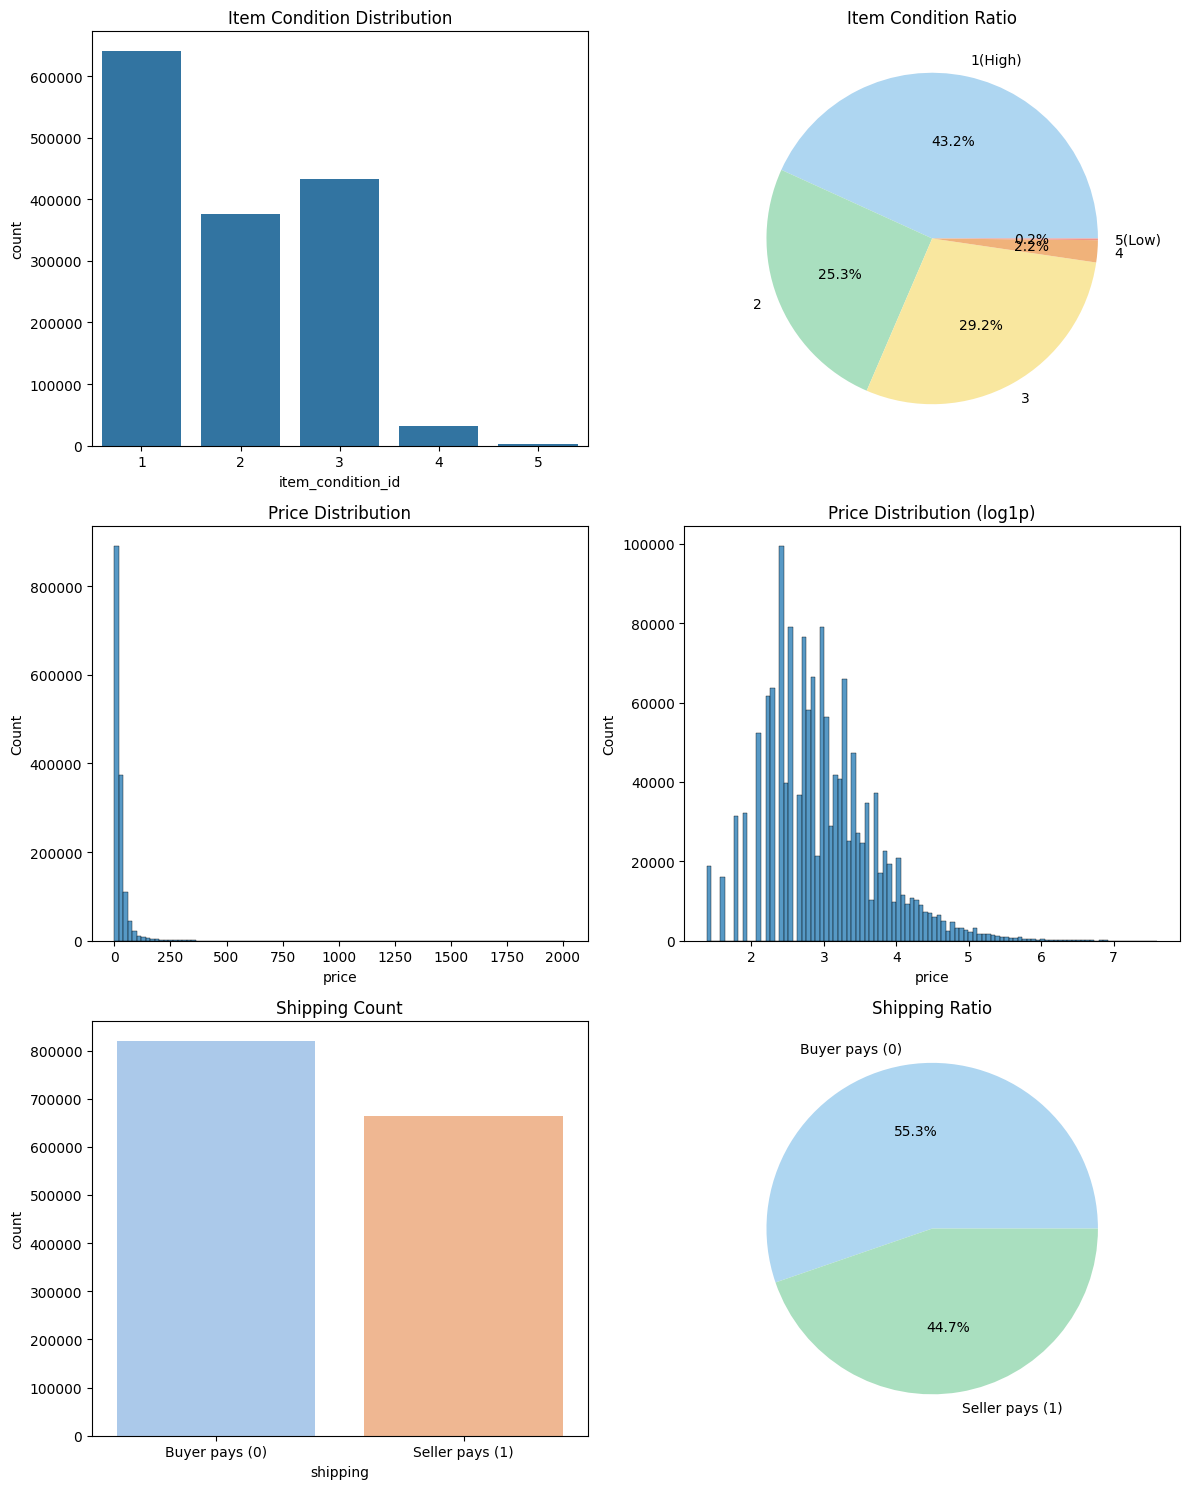

In [159]:
# 수치형 컬럼의 시각화

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

# item_condition_id: 카테고리형과 유사 -> countplot
sns.countplot(x='item_condition_id', data=train, ax=axes[0])
axes[0].set_title('Item Condition Distribution')

# item_condition_id 비율 확인 : pie-chart
condition_counts = train['item_condition_id'].value_counts().sort_index()
axes[1].pie(condition_counts, 
            labels=['1(High)', '2', '3', '4', '5(Low)'],
            autopct='%1.1f%%', 
            colors=['#AED6F1', '#A9DFBF', '#F9E79F', '#F0B27A', '#F1948A'])
axes[1].set_title('Item Condition Ratio')

# price: 가격은 보통 심하게 오른쪽으로 치우쳐 있음 (right-skewed)
sns.histplot(train['price'], bins=100, ax=axes[2])
axes[2].set_title('Price Distribution')

# price 로그 변환
sns.histplot(train['price'][train['price'] > 0].apply(np.log1p), bins=100, ax=axes[3])
axes[3].set_title('Price Distribution (log1p)')

# shipping : 카테고리형과 유사 -> Countplot (절대적인 빈도 확인)
sns.countplot(x='shipping', data=train, ax=axes[4], palette='pastel')
axes[4].set_title('Shipping Count')
axes[4].set_xticklabels(['Buyer pays (0)', 'Seller pays (1)'])

# shipping 비율 확인 : Pie chart
shipping_counts = train['shipping'].value_counts()
axes[5].pie(shipping_counts, 
            labels=['Buyer pays (0)', 'Seller pays (1)'],
            autopct='%1.1f%%', 
            colors=['#AED6F1', '#A9DFBF'])
axes[5].set_title('Shipping Ratio')

plt.tight_layout()
plt.show()

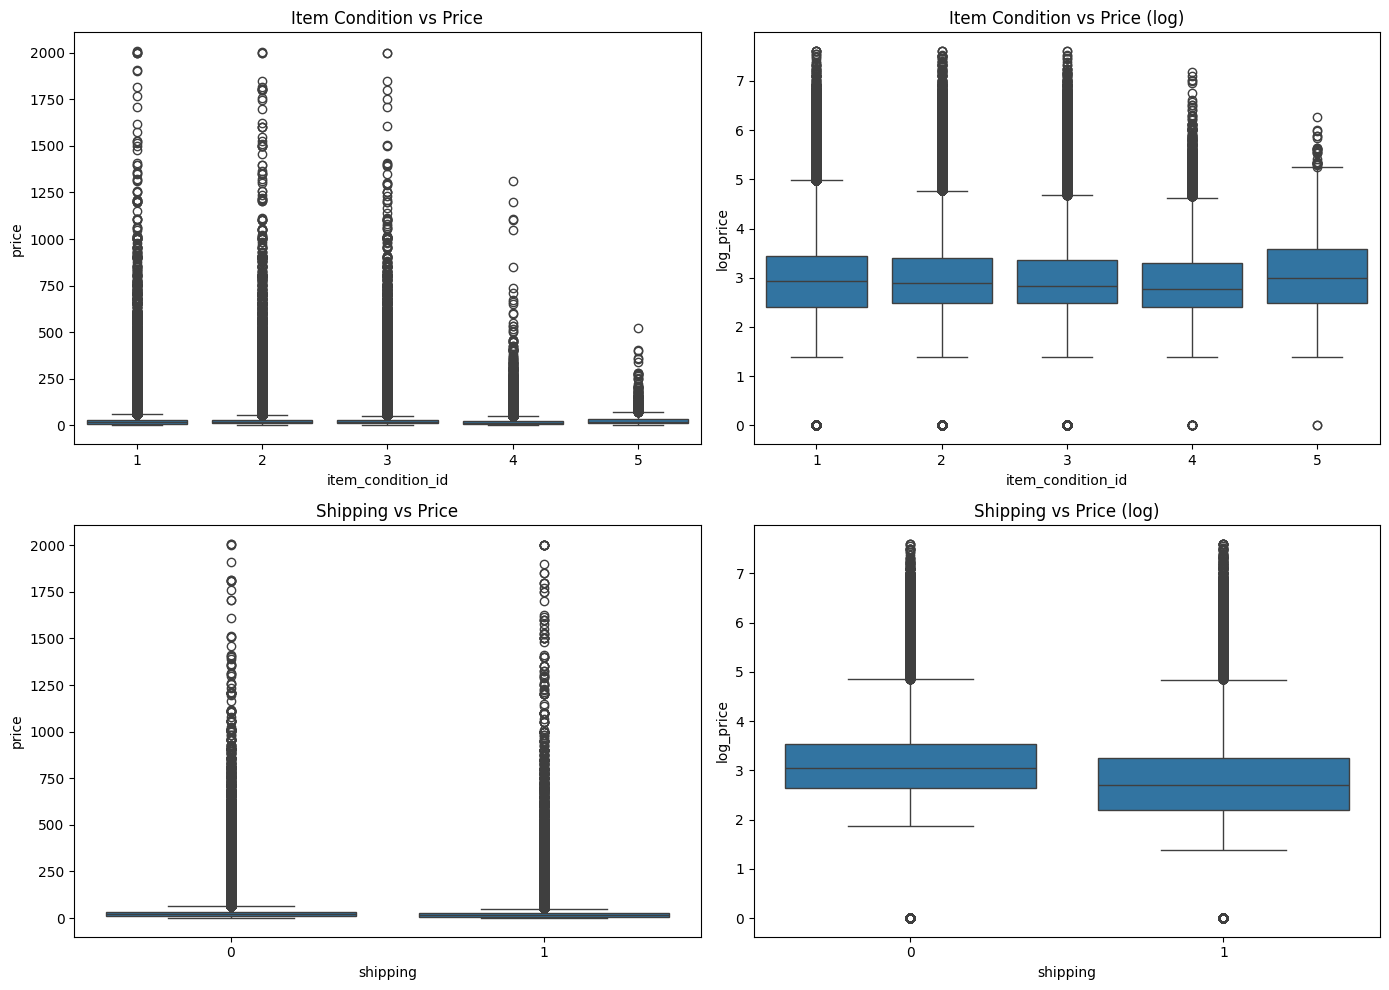

In [160]:
# price와 'item_condition_id', 'shipping' 사이의 이변량 분석

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# price 로그변환 컬럼 생성
train['log_price'] = np.log1p(train['price'])

# item_condition_id - 원본 price
sns.boxplot(x='item_condition_id', y='price', data=train, ax=axes[0][0])
axes[0][0].set_title('Item Condition vs Price')

# item_condition_id - log price (왜도 보정)
sns.boxplot(x='item_condition_id', y='log_price', data=train, ax=axes[0][1])
axes[0][1].set_title('Item Condition vs Price (log)')

# shipping - 원본 price
sns.boxplot(x='shipping', y='price', data=train, ax=axes[1][0])
axes[1][0].set_title('Shipping vs Price')

# shipping - log price
sns.boxplot(x='shipping', y='log_price', data=train, ax=axes[1][1])
axes[1][1].set_title('Shipping vs Price (log)')

plt.tight_layout()
plt.show()

In [161]:
# boxplot의 중앙값, 평균 확인
print("=== Item Condition별 Price 중앙값 및 평균 ===")
print(train.groupby('item_condition_id')['price'].agg(['median','mean']).round(2))

print("\n=== Shipping별 Price 중앙값 및 평균 ===")
print(train.groupby('shipping')['price'].agg(['median','mean']).round(2))

print("\n=== Item Condition별 log_price 중앙값 및 평균 ===")
print(train.groupby('item_condition_id')['log_price'].agg(['median','mean']).round(4))

print("\n=== Shipping별 log_price 중앙값 및 평균 ===")
print(train.groupby('shipping')['log_price'].agg(['median','mean']).round(4))

=== Item Condition별 Price 중앙값 및 평균 ===
                   median   mean
item_condition_id               
1                    18.0  26.49
2                    17.0  27.56
3                    16.0  26.54
4                    15.0  24.35
5                    19.0  31.70

=== Shipping별 Price 중앙값 및 평균 ===
          median   mean
shipping               
0           20.0  30.11
1           14.0  22.57

=== Item Condition별 log_price 중앙값 및 평균 ===
                   median    mean
item_condition_id                
1                  2.9444  2.9727
2                  2.8904  3.0007
3                  2.8332  2.9752
4                  2.7726  2.8960
5                  2.9957  3.0925

=== Shipping별 log_price 중앙값 및 평균 ===
          median    mean
shipping                
0         3.0445  3.1339
1         2.7081  2.7877


##### 3-1-2. 이변량 분석 - item_condition_id(상품 컨디션)와 shipping(배송비) 관계 확인

In [162]:
# 교차표 - 빈도수
print("=== Item Condition x Shipping 교차표 (빈도) ===")
print(pd.crosstab(train['item_condition_id'], train['shipping']))

# 교차표 - 비율 (행 기준, 각 컨디션별 shipping 비율)
print("\n=== Item Condition x Shipping 교차표 (행 기준 비율) ===")
print(pd.crosstab(train['item_condition_id'], train['shipping'], normalize='index').round(4))

=== Item Condition x Shipping 교차표 (빈도) ===
shipping                0       1
item_condition_id                
1                  280107  360442
2                  232509  142970
3                  283691  148470
4                   21603   10359
5                    1525     859

=== Item Condition x Shipping 교차표 (행 기준 비율) ===
shipping                0       1
item_condition_id                
1                  0.4373  0.5627
2                  0.6192  0.3808
3                  0.6564  0.3436
4                  0.6759  0.3241
5                  0.6397  0.3603


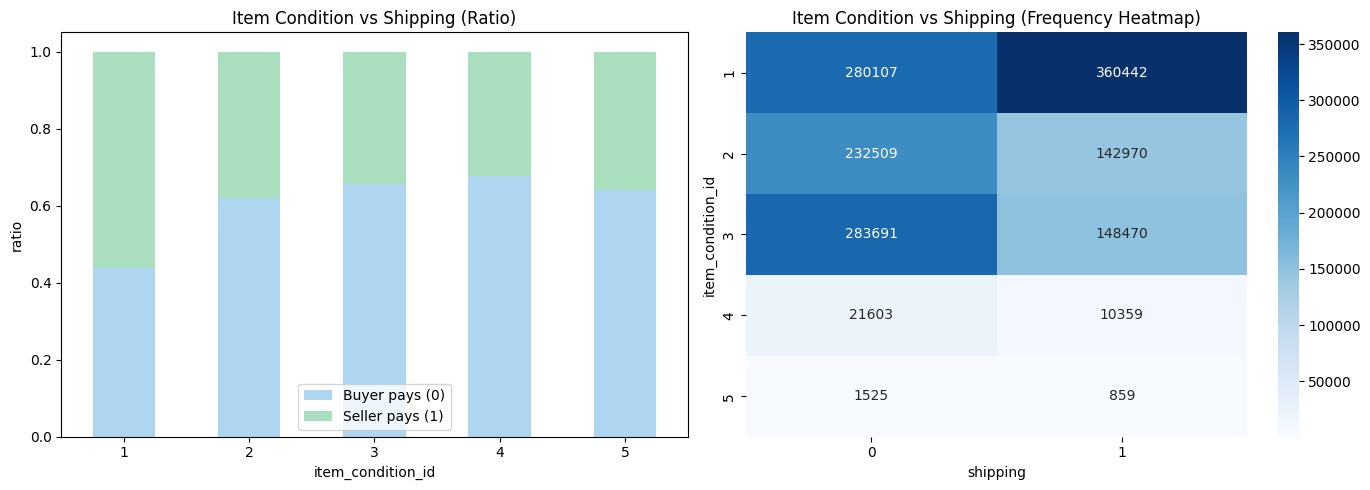

In [163]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 누적 막대그래프 - 컨디션별 shipping 비율 비교
ct = pd.crosstab(train['item_condition_id'], train['shipping'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#AED6F1', '#A9DFBF'])
axes[0].set_title('Item Condition vs Shipping (Ratio)')
axes[0].set_xlabel('item_condition_id')
axes[0].set_ylabel('ratio')
axes[0].legend(['Buyer pays (0)', 'Seller pays (1)'])
axes[0].tick_params(axis='x', rotation=0)

# 2. 히트맵 - 빈도수 기반
ct_count = pd.crosstab(train['item_condition_id'], train['shipping'])
sns.heatmap(ct_count, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Item Condition vs Shipping (Frequency Heatmap)')

plt.tight_layout()
plt.show()

In [164]:
# 'item_condition_id'과 배송비 부담에 따른 상품의 '평균 / 중앙값 / 상품수' 비교
pd.pivot_table(
    train,
    values='price',
    index='item_condition_id',
    columns='shipping',
    aggfunc=['mean','median','count']
)

mean            median         count        
shipping                   0          1      0     1       0       1
item_condition_id                                                   
1                  33.011762  21.416412   23.0  14.0  280107  360442
2                  29.573047  24.294695   19.0  15.0  232509  142970
3                  28.026705  23.701327   18.0  15.0  283691  148470
4                  25.472504  22.006661   16.0  12.0   21603   10359
5                  33.188852  29.067520   20.0  16.0    1525     859

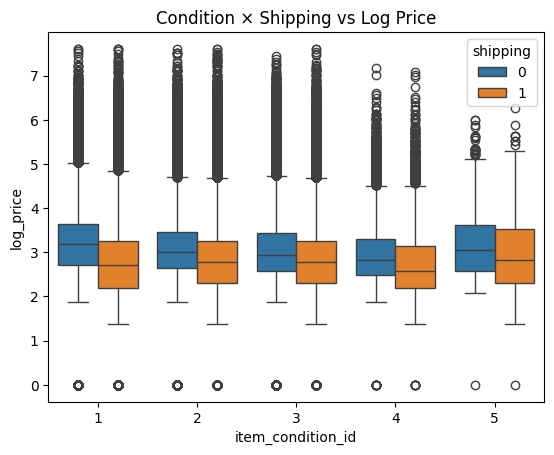

[상품 컨디션에 따른 상품 가격 분포 - 배송비 부담에 따른 구분]


In [165]:
sns.boxplot(
    x='item_condition_id',
    y='log_price',
    hue='shipping',
    data=train
)
plt.title("Condition × Shipping vs Log Price")
plt.show()
print('[상품 컨디션에 따른 상품 가격 분포 - 배송비 부담에 따른 구분]')

---
##### 3-1-3. **수치형 컬럼에 대한 분석 결과 요약**  

- 'item_condition_id' :   
    1. 판매하고자 하는 상품의 상태는 1(High)에서 5(Low)의 5단계로 분류되어 있다.     
    2. 물품의 품질이 높은 상태(1)인 경우가 전체의 43.2%를 차지하며, 3(29.2%) → 2(25.3%) → 4(2.2%) → 5(0.2%) 순으로 나타난다.     
    3. 전반적으로 컨디션이 좋은 상품일 수록 가격이 높은 경향을 확인할 수 있다. (1-3등급에서 1,500 이상의 고가 상품의 분포를 확인할 수 있다.)   
    4. 컨디션이 5인 상품의 중앙값이 가장 높은 결과를 토대로 낮은 컨디션 상품도 의외로 가격이 낮지 않은 경우가 많다는 것을 확인할 수 있다.  
    5. 상품의 컨디션보다 다른 요소가 가격에 더 큰 영향을 줄 수 있다는 것을 반증한다.   
    6. 컨디션이 1-3에 판매 상품이 집중되어 있는 것을 히트맵을 통해서 확인할 수 있다. 
- 'price' :   
    1. 전체 상품의 평균은 26.7375이며 중앙값은 17이다. std는 38.58607로 가격이 넓게 분포된 것을 확인할 수 있다.   
    2. 원본 price의 그래프에서 보이듯 가격은 오른쪽으로 심하게 치우쳐 있음을 확인할 수 있다.  
- 'shipping' :   
    1. 배송비(shipping)과 가격(price)의 상관관계에 있어서, 배송비가 구매자 부담(0)인 경우, 중앙값이 20으로 판매자 부담(1)인 경우(14)보다 높다.   
    2. 판매자가 배송비를 포함하여 가격을 책정하는 전략을 사용하거나, 저가 상품 판매에 있어 판매자가 배송비를 부담하는 경향이 있음을 확인할 수 있다.  
    3. 상품의 컨디션이 가장 좋은 상품(item_condition_id : 1)에서만 판매자의 배송비 부담비율이 과반수를 넘는다. 나머지 등급에서는 소비자의 배송비 부담이 60%대로 더 높은 경향을 확인할 수 있다.    
    4. 컨디션 1인 상품에 있어서 판매자가 배송비를 부담하는 건수는 360,442건으로 전체 데이터 1,482,535건 중 24.31%를 차지하는 것으로 전체에서 가장 큰 비중을 차지하고 있음을 확인할 수 있다.   

**💡[Insights]**  
- 'item_condition_id' x 'shipping' 조합 고려 : 상품의 컨디션과 배송비간의 상호관계에 대한 추가 범주형 데이터 설정 및 분석   
- 방향 : 단순 조합
- 코드 : train['condition_x_shipping'] = train['item_condition_id'].astype(str) + '_' + train['shipping'].astype(str)  
- 결과 예시: '1_0', '1_1', '2_0', '2_1' ... 총 10가지 조합 

#### 3-2. 범주형 컬럼  

##### 3-2-1. 단변량 분석

In [166]:
print("=== 범주형 컬럼 기본 현황 ===")
cat_cols = ['name', 'category_name', 'brand_name', 'item_description']
for col in cat_cols:
    print(f"{col}: 고유값 {train[col].nunique():,}개")

=== 범주형 컬럼 기본 현황 ===
name: 고유값 1,225,273개
category_name: 고유값 1,288개
brand_name: 고유값 4,810개
item_description: 고유값 1,281,425개


**💡[Insights]**  
- 'name'과 'item_description' 컬럼  
    : 고유값의 개수가 'name' 컬럼의 경우, 1,225,273개(전체 데이터의 82.65%)이고 'item_description' 컬럼의 경우, 1,281,425개(전체 데이터의 86.43%)를 나타낸다. 전반적으로 개개의 데이터에 포함되어 있는 정보를 텍스트 길이나 자연어 분석을 통하여 상품 가격에 영향을 미치는 요소를 찾는다.     
- 'category_name'과 'brand_name' 컬럼 (결측치 'No category/No category/No category', 'No Brand' 포함) 
    : 각 컬럼의 개수가 'category_name' 컬럼의 경우, 1,288개, 'brand_name' 컬럼의 경우 4,810개로 고유값으로 그룹화가 가능한 것을 확인할 수 있다.   
      이 두 개의 컬럼에 있어, 상위 30개의 목록을 확인하고, 이에 대한 추가적인 확인을 통하여 가격 예측 변수의 특징을 확인할 수 있다. 

Text(0.5, 1.0, 'Item Description Length Distrubution')

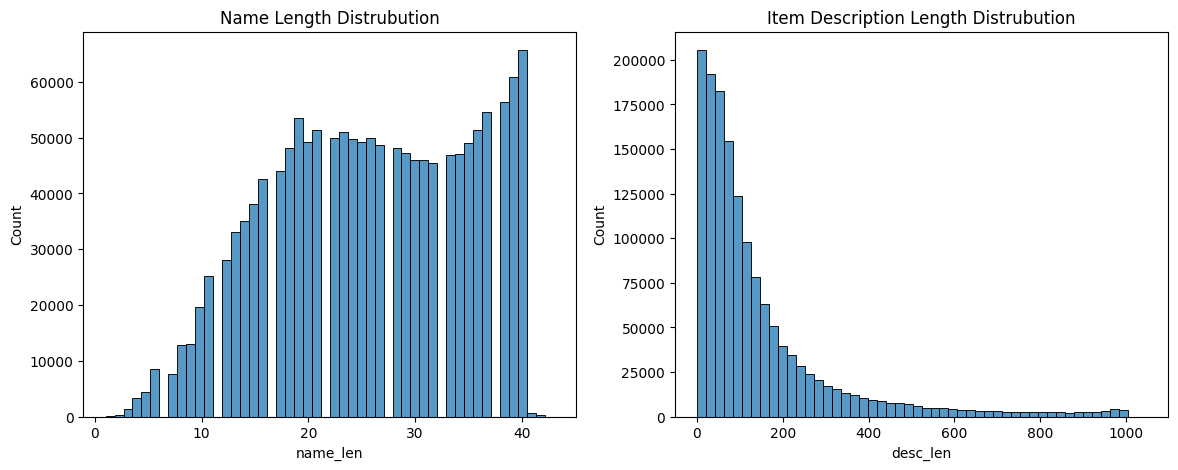

In [167]:
# 'name', 'item_description' 컬럼의 텍스트 길이 분석
train['name_len'] = train['name'].str.len()
train['desc_len'] = train['item_description'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['name_len'], bins=50, ax=axes[0])
axes[0].set_title('Name Length Distrubution')

sns.histplot(train['desc_len'], bins=50, ax=axes[1])
axes[1].set_title('Item Description Length Distrubution')

**💡[Insights]**  
- 'name'의 길이에 따른 상품 분포 :  
    1. 분포가 쌍봉의 형태를 나타낸다. 20자 근처와 40자 근처에서 높은 빈도수를 확인할 수 있다.      
    2. 글자수의 길이에 제한을 추정할 수 있다.  
    3. 판매자에 있어 상품의 설명을 짧게 핵심만 작성하는 유형과 길게 쓰는 판매자의 유형이 존재하는 것을 추정할 수 있다.   
    => 길이 자체를 새로운 feature로 활용 가능
- 'item_description' 길이에 따른 상품 분포 :    
    1. 오른쪽으로 꼬리가 긴 분포를 나타낸다.   
    2. 상품의 설명이 200자 이내에 집중되어 있는 것을 확인할 수 있다.  
    3. 0-20자 구간에 많은 상품이 모여있는 것으로 보아, 해당 구간에 결측치 또는 item_description의 기본값인 'No description yet'으로 기재된 상품의 데이터가 포함되어 있을 가능성이 높게 추정된다.   
       => 확인결과 'No description yet'으로 기재된 데이터수는 82,495개로 전체 데이터의 약 5.56%를 차지한다.   
       => item_description의 길이와 가격과의 상관관계에 대하여 추가 확인이 필요하다.  
       => item_description 유/무가 판매 가격에 영향을 미치는지 여부에 대해서 추가 확인이 필요하다.  

In [168]:
# item_description에 'No description yet'으로 작성된 상품의 개수 및 비율 확인
no_desc = train[train['item_description'] == 'No description yet']
print(f"'No description yet' 개수: {len(no_desc):,}")
print(f"전체 대비 비율: {len(no_desc)/len(train)*100:.2f}%")

'No description yet' 개수: 82,495
전체 대비 비율: 5.56%


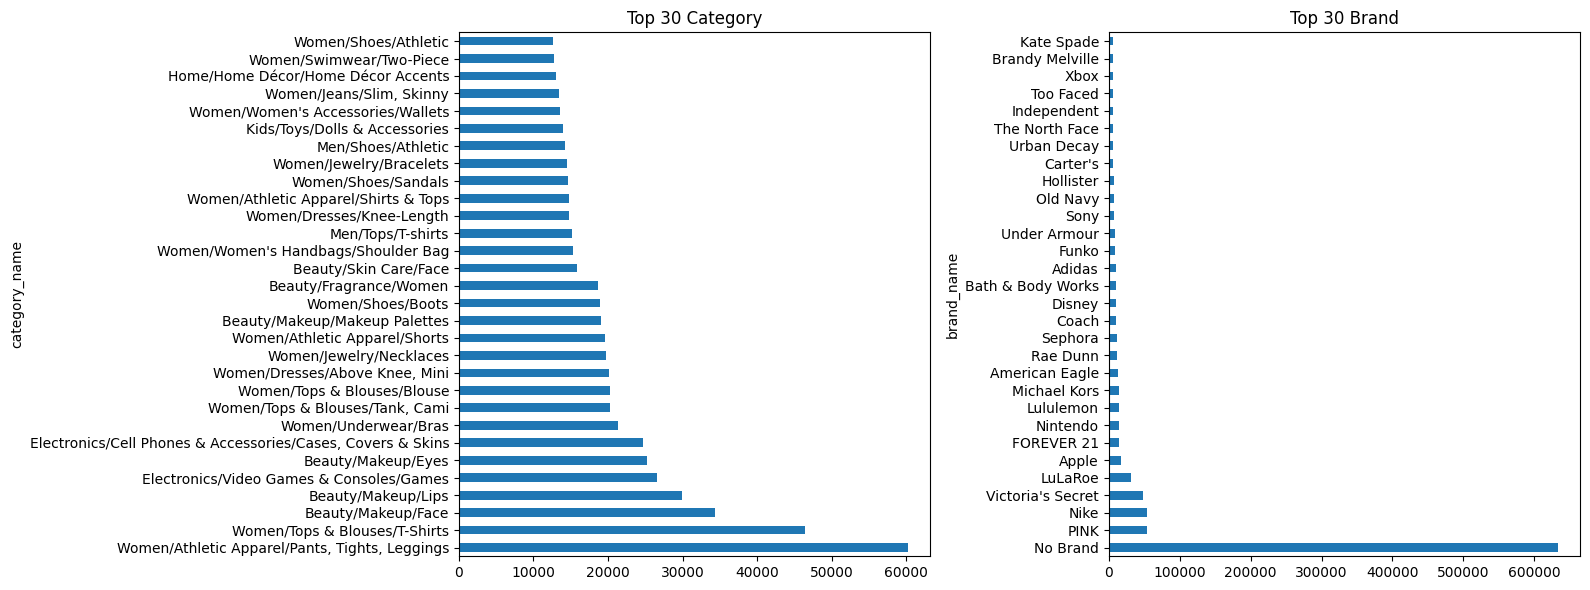

In [169]:
# 'category_name', 'brand_name'의 Top 30 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train['category_name'].value_counts().head(30).plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 30 Category')

train['brand_name'].value_counts().head(30).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 30 Brand')

plt.tight_layout()
plt.show()

**💡[Insights]**  
- 'category_name'Top 30 분석 :  
    1. 'Women' 카테고리가 압도적으로 많은 것을 확인할 수 있다. (Top 30개 중 18개)   
    2. 앞서 'Women' 카테고리에 속한 상품의 개수에 있어서 664,385개(전체의 44.81%)로 Mercari 사이트가 여성 사용자 중심 플랫폼임을 추정할 수 있다.  
    3. 'Women'다음으로 'Beauty' 카테고리 상품(207,828개 / 14.01%)가 활발하게 거래되는 것을 확인할 수 있다. 
- 'brand_name' Top 30 분석 :    
    1. 'No Brand'에 속한 상품이 632,682건으로 전체 브랜드 분포에 있어서 압도적으로 우위를 차지하고 있음을 확인할 수 있다.  
    => 전체 데이터의 42.68% 결측치에 대한 확인이 필요한 것을 반증하고 있다.     
    2. 'No Brand'를 제외하고, PINK, Nike, Victoria'secret, LuLaRoe 순으로 앞서 category_name에서 'Women' 카테고리 비중의 차지하는 것과 일치하는 패턴을 확인할 수 있다.    

---
(추가) 브랜드가 없는 상품들의 가격 분포 확인 : 'Women' 카테고리가 전체 30개 중 12개를 차지하며, 'Beauty' 카테고리가 7개로 확인된다.

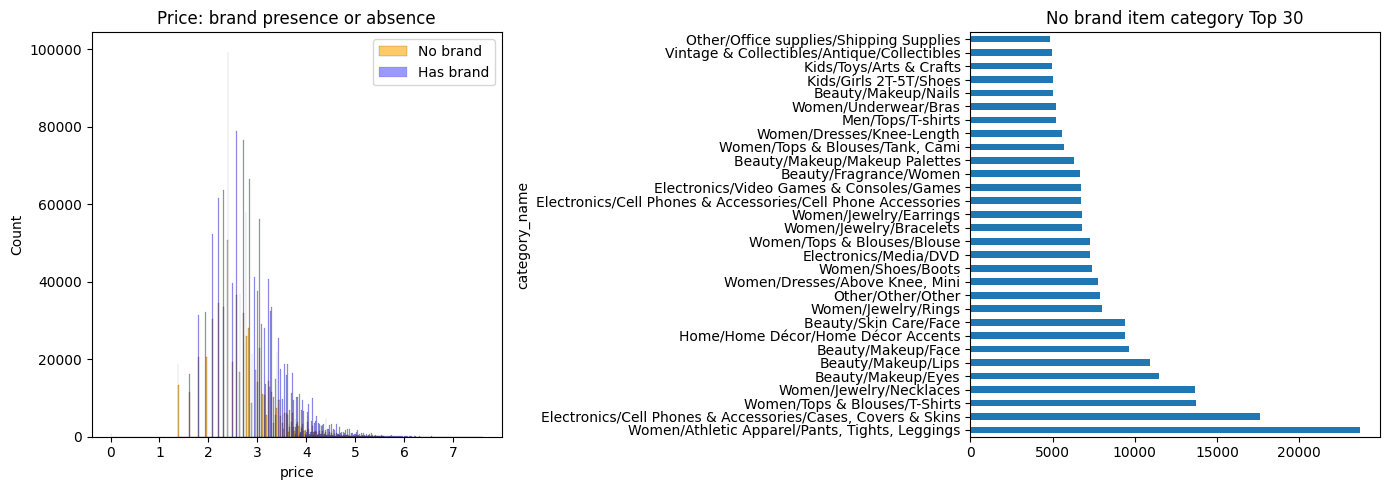

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(no_brand['price'][no_brand['price'] > 0].apply(np.log1p), 
             ax=axes[0], label='No brand', color='orange', alpha=0.6)
sns.histplot(train[train['brand_name'] != 'No brand']['price'].apply(np.log1p),
             ax=axes[0], label='Has brand', color='blue', alpha=0.4)
axes[0].set_title('Price: brand presence or absence')
axes[0].legend()

# 브랜드 없는 상품의 카테고리 분포
no_brand['category_name'].value_counts().head(30).plot(kind='barh', ax=axes[1])
axes[1].set_title('No brand item category Top 30')

plt.tight_layout()
plt.show()

---
category_name 분류에 따른 분포 :   
- 전체 1,287개의 카테고리와 카테고리가 반영되지 않은 'No category/No category/No category' 
- 기존 데이터의 형식을 반영하여 앞서 '대분류(cat_1)','중분류(cat_2)','소분류(cat_3)'으로 분류한 내역에 대한 세부 분석

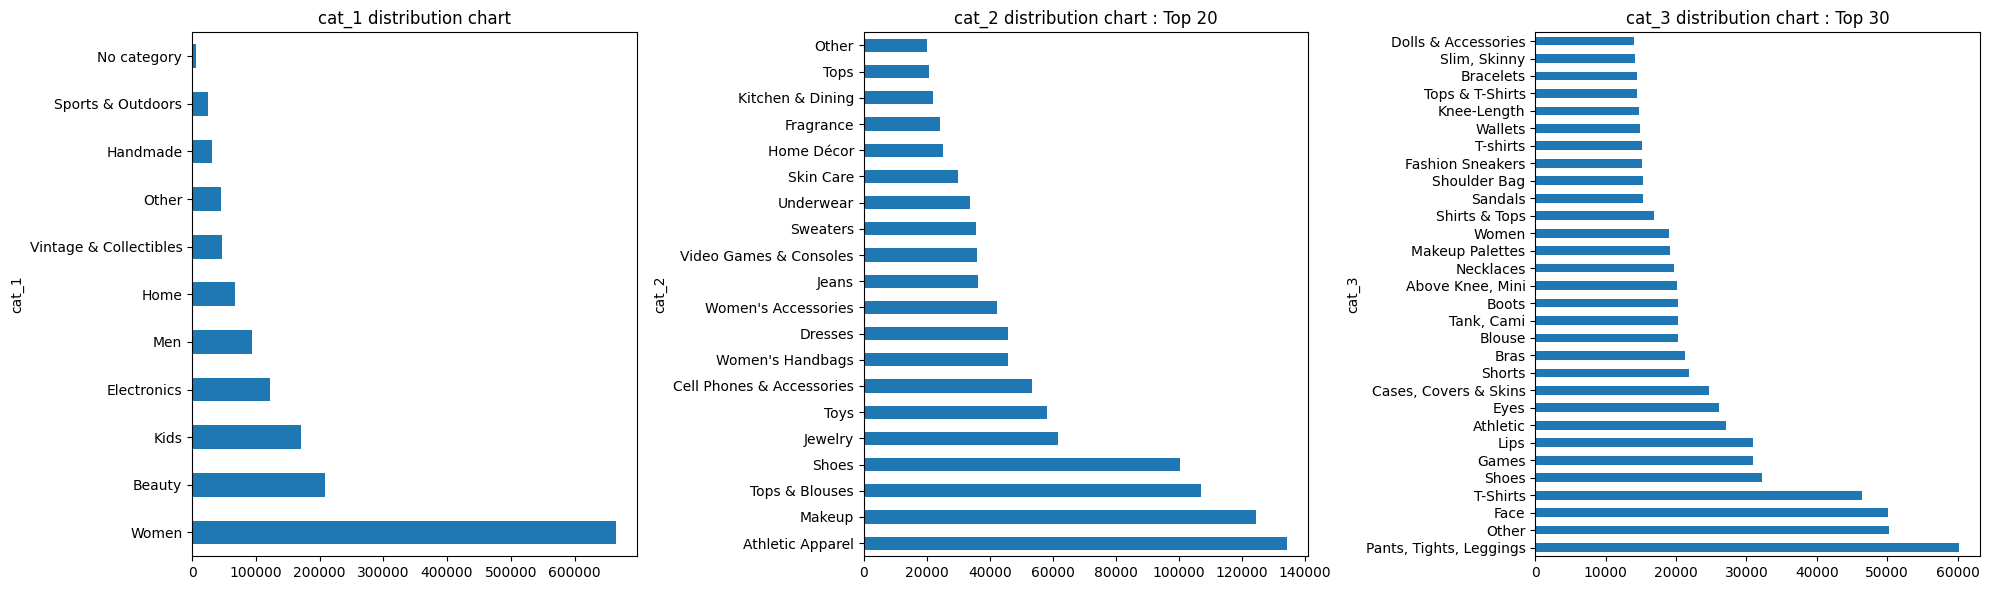

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# cat_1: 대분류 (전체 분포 확인)
train['cat_1'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('cat_1 distribution chart')

# cat_2: 중분류 Top 20 (전체 114개 중 상위 20개 항목 확인)
train['cat_2'].value_counts().head(20).plot(kind='barh', ax=axes[1])
axes[1].set_title('cat_2 distribution chart : Top 20')

# cat_3: 소분류 Top 30 (전체 872개 중 상위 30개 항목 확인)
train['cat_3'].value_counts().head(30).plot(kind='barh', ax=axes[2])
axes[2].set_title('cat_3 distribution chart : Top 30')

plt.tight_layout()
plt.show()

**💡[Insights]** : 카테고리 대분류(cat_1), 중분류(cat_2), 소분류(cat_3)  
- 'cat_1' 전체 분포 분석 :  
    1. 'Women' > 'Beauty' > 'Kids' > 'Electronis' > 'Men' > 'Home' 의 순으로 판매 상품의 구성을 확인할 수 있다.  
    2. 'Women' 카테고리에 속한 상품의 개수가 'Beauty', 'Kids', 'Electronis', 'Men'를 합친 것보다 많은 것을 확인할 수 있다.  
    3. 'Men' 카테고리에 속한 상품의 개수(93,680개)와 'Women' 카테고리에 속한 상품의 개수(664,385개)와 비교했을 대, 'Women' 카테고리에 속한 상품이 약 7배 이상임을 확인할 수 있다. Mercari 사이트가 여성 사용자 중심 플랫폼임을 재확인할 수 있다.  
- 'cat_2' Top 20 분석 :    
    1. 'cat_2' 카테고리의 고유값은 114개로 상위 20개의 항목에 대한 분포를 확인하였다.   
    2. 'Athletic Apparel' > 'Makeup' > ' Tops & Blouses' > 'Shoes' > 'Jewelry' > 'Toys' > 'Cell Phones & Accessories' > 'Women's Handbags' > 'Dress' > 'Women's Accessories' 의 순으로 카테고리가 구성되어 있다. 
    3. 중분류의 상품 구분에 있어서도 'Women'과 관련된 상품의 카테고리가 많은 비중을 차지함을 확인할 수 있다.   
- 'cat_3' Top 30 분석 :  
    1. 'Pants, Tights, Legings'가 압도적으로 많은 상품을 구성하고 있다.   
    2. 2순위인 'Other'의 비중이 높은 것으로 소분류 자체가 세분화되어 있지 않은 상품이 많다는 것을 확인할 수 있다.   
    
=> 'Women / Athletic Apparel/Pants,Tights,Leggings'의 조합이 전체적으로 가장 지배적인 카테고리임을 재확인할 수 있다. (앞서 구분되지 않은 'category_name' 컬럼으로 분포를 분석한 결과와 동일함을 알 수 있다.)  
=> 'Men' 카테고리에 있어 상품수가 적고, 'Women'의 카테고리와 중복되는 중분류(cat_2)가 존재한다. 결측치 처리 및 모델 학습시 불균형을 주의해야 할 것으로 보인다.  

##### 3-2-2. 이변량 분석  

3-2-2-1 cat_1와 price와의 상관관계

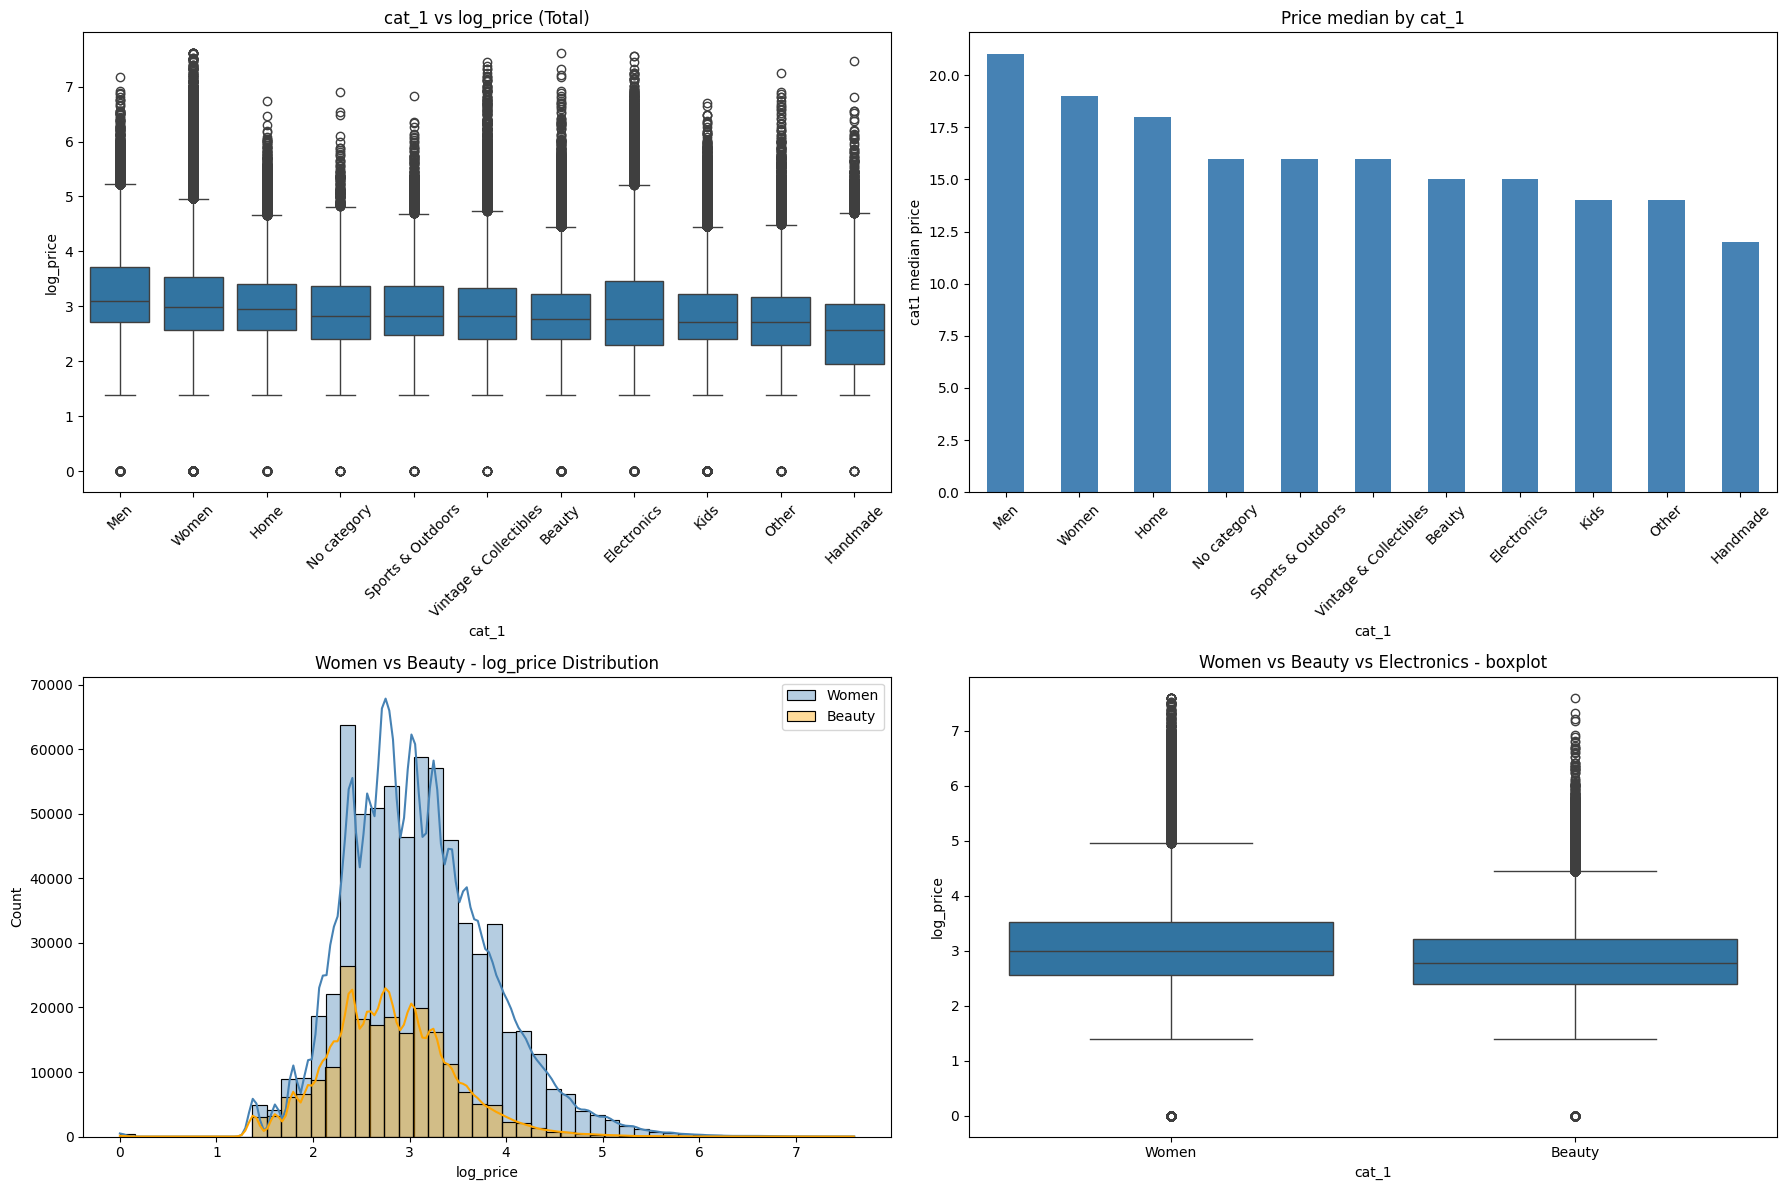

In [172]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. 전체 cat_1 x log_price 박스플롯
cat1_price = train.groupby('cat_1')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='cat_1', y='log_price', data=train, order=cat1_price, ax=axes[0][0])
axes[0][0].set_title('cat_1 vs log_price (Total)')
axes[0][0].tick_params(axis='x', rotation=45)

# 2. 전체 cat_1별 중앙값 barplot
cat1_median_price = train.groupby('cat_1')['price'].median().sort_values(ascending=False)
cat1_median_price.plot(kind='bar', ax=axes[0][1], color='steelblue')
axes[0][1].set_title('Price median by cat_1')
axes[0][1].tick_params(axis='x', rotation=45)
axes[0][1].set_ylabel('cat1 median price')

# 3. 최다 판매 카테고리 log_price 분포 비교 - histplot
target_cats = ['Women', 'Beauty']
cat_filter = train[train['cat_1'].isin(target_cats)]
for cat, color in zip(target_cats, ['steelblue', 'orange']):
    sns.histplot(train[train['cat_1'] == cat]['log_price'],
                bins=50,
                kde=True,           
                color=color,
                alpha=0.4,          
                label=cat,
                ax=axes[1][0])
axes[1][0].set_title('Women vs Beauty - log_price Distribution')
axes[1][0].legend()

# 4. 최다 판매 카테고리 박스플롯 비교
sns.boxplot(x='cat_1', y='log_price', data=cat_filter, order=target_cats, ax=axes[1][1])
axes[1][1].set_title('Women vs Beauty vs Electronics - boxplot')

plt.tight_layout()
plt.show()


In [173]:
# 수치 확인 - 원본 price
print("=== 전체 cat_1별 Price 통계 ===")
print(train.groupby('cat_1')['price'].describe().round(2))

print("\n=== 최다 판매 카테고리('Women','Beauty') 비교 ===")
print(train[train['cat_1'].isin(target_cats)].groupby('cat_1')['price'].describe().round(2))


=== 전체 cat_1별 Price 통계 ===
                           count   mean    std  min   25%   50%   75%     max
cat_1                                                                        
Beauty                  207828.0  19.67  21.36  0.0  10.0  15.0  24.0  2000.0
Electronics             122690.0  35.17  65.42  0.0   9.0  15.0  31.0  1909.0
Handmade                 30842.0  18.16  27.76  0.0   6.0  12.0  20.0  1750.0
Home                     67871.0  24.54  24.42  0.0  12.0  18.0  29.0   848.0
Kids                    171689.0  20.64  22.73  0.0  10.0  14.0  24.0   809.0
Men                      93680.0  34.71  41.24  0.0  14.0  21.0  40.0  1309.0
No category               6327.0  25.39  34.11  0.0  10.0  16.0  28.0  1000.0
Other                    45351.0  20.81  29.85  0.0   9.0  14.0  23.0  1400.0
Sports & Outdoors        25342.0  25.53  29.30  0.0  11.0  16.0  28.0   915.0
Vintage & Collectibles   46530.0  27.34  53.51  0.0  10.0  16.0  27.0  1709.0
Women                   664385.0  28.

In [174]:
# 수치 확인 - Log_price
print("=== 전체 cat_1별 Log Price 기술통계 ===")
print(train.groupby('cat_1')['log_price'].describe().round(2))

print("\n=== 최다 판매 카테고리('Women','Beauty') 비교 ===")
print(train[train['cat_1'].isin(target_cats)].groupby('cat_1')['log_price'].describe().round(2))

=== 전체 cat_1별 Log Price 기술통계 ===
                           count  mean   std  min   25%   50%   75%   max
cat_1                                                                    
Beauty                  207828.0  2.80  0.63  0.0  2.40  2.77  3.22  7.60
Electronics             122690.0  2.99  0.95  0.0  2.30  2.77  3.47  7.55
Handmade                 30842.0  2.58  0.79  0.0  1.95  2.56  3.04  7.47
Home                     67871.0  2.99  0.67  0.0  2.56  2.94  3.40  6.74
Kids                    171689.0  2.81  0.67  0.0  2.40  2.71  3.22  6.70
Men                      93680.0  3.23  0.77  0.0  2.71  3.09  3.71  7.18
No category               6327.0  2.94  0.75  0.0  2.40  2.83  3.37  6.91
Other                    45351.0  2.75  0.73  0.0  2.30  2.71  3.18  7.24
Sports & Outdoors        25342.0  2.97  0.72  0.0  2.48  2.83  3.37  6.82
Vintage & Collectibles   46530.0  2.90  0.82  0.0  2.40  2.83  3.33  7.44
Women                   664385.0  3.08  0.73  0.0  2.56  3.00  3.53  7.61

=== 

---
**💡[Insights]** 
- 'cat_1' 과 'log_price'와의 관계 분석 :  
    1. 'Men' 카테고리에 속한 상품의 중앙값(21)이 'Women' 카테고리에 속한 상품의 중앙값(19)보다 높은 것을 확인할 수 있다. 앞서 확인한 전체 상품에서 'Men'이 차지하는 비중은 'Women'보다 수량에서는 작지만 단가가 높은 상품 위주로 거래되는 경향을 확인할 수 있다.   
    2. 'Home' 카테고리 상품의 중앙값은 18로 전체 대분류 카테고리(cat_1)에서 3위를 차지한다. 가구/인테리어 상품의 가격대가 높음을 추정할 수 있다.    
    3. 모든 카테고리에 있어 이상치(고가 상품)이 광범위하게 존재하는 것을 확인할 수 있다.   
    4. 박스(IQR)의 크기에 있어서, 'Women'과 'Electronics' 박스의 크기가 넓고, 'Beauty'와 'Kids'의 크가가 상대적으로 좁은 것을 확인할 수 있다.   
    5. 'Vintage & Collectibles'과 'Beauty'의 수염(whisker)가 다른 카테고리에 비해 긴 형태를 나타내고 있으며, 고가 상품 비중이 높을 가능성을 추정해볼 수 있다.  
- 'price'중앙값 :    
    1. 'Men(21) > Women(19) > Home(18) > No category(16), Sports & Outdoors(16), Vintage & Collectibles(16) > Beauty(15), Electronics(15) > Kids(4), Other(14) > Handmade(12)'와 같이 12~21달러 사이로 나타난다. 전체적인 가격의 분포가 0 ~ 2000인 것을 반영하면 중앙값은 차이가 크지 않다.    
    2. 'No category'의 중앙값이 16로, 결측치라도 가격 분포가 일반적인 범주에서 크게 벗어나지 않음을 확인할 수 있다.     
- 최다 판매 카테고리('Women', 'Beauty') 분석 :  
    1. 'Women' 카테고리의 상품군이 'Beauty' 카테고리 상품군에 비해 훨씬 많은 상품이 분포되어 있음을 재확인할 수 있다.   
    2. 'Beauty' 카테고리의 상품군은 log_price 기준 2-3구간에 집중되어 있고, 분포가 좁다. 뷰티 상품의 가격대가 Boxplot에서 확인한 것과 같이 일정 범위에 몰려있다는 것을 확인할 수 있다.  
    3. 'Women' 카테고리의 상품군은 1-6 구간에 걸쳐 넓게 분포하는 것을 확인할 수 있따. 다양한 상품군이 혼재하는 것을 추정할 수 있다.  
    4. 'Women', 'Beauty' 카테고리 모두 다봉 형태의 분포를 확인할 수 있다. 카테고리 내에도 가격대가 다른 세부 상품군이 존재한다는 결과를 도출할 수 있다.      
    
=> 'Women'과 'Beauty' 카테고리에 속하는 상품의 경우, 중분류(cat_2)에 따른 세부 가격분포를 추가적으로 확인해 보도록 한다. 

In [175]:
# 결측 카테고리 상품들 — 다른 컬럼으로 패턴 파악
print(f"Missing category_name Ratio: {len(no_category)/len(train)*100:.2f}%")

# 브랜드와의 관계: 카테고리 없는 상품과 브랜드와의 관계 확인
print("\nBrand Status:")
print(no_category['brand_name'].value_counts().head(10))

# 가격 분포 비교
print("\nPrice Statistics:")
print(pd.DataFrame({
    'category(o)': train[train['cat_1'] != 'No category']['price'].describe(),
    'category(x)': no_category['price'].describe()
}))

Missing category_name Ratio: 0.43%

Brand Status:
brand_name
No Brand             3457
PINK                  158
LuLaRoe               151
Victoria's Secret     101
Nike                   83
FOREVER 21             81
Pokemon                79
Disney                 75
American Eagle         68
Brandy Melville        44
Name: count, dtype: int64

Price Statistics:
        category(o)  category(x)
count  1.476208e+06  6327.000000
mean   2.674327e+01    25.394658
std    3.860403e+01    34.114422
min    0.000000e+00     0.000000
25%    1.000000e+01    10.000000
50%    1.700000e+01    16.000000
75%    2.900000e+01    28.000000
max    2.009000e+03  1000.000000


**💡[Insights]**  
- 'Electronics'는 중앙값이 15이며, 전체 데이터의 평균값과 상위 5%를 제외한 데이터의 평균값의 차이가 16.6이며 std 역시 압도적으로 크다. 이는 저가 상품과 고가 상품이 혼재되어 있는 것으로 추정할 수 있다.   이를 토대로 'cat_2','cat_3' 세분화된 분석이 필요할 것으로 보인다.  
- 추가적으로 'Men'과 'Vintage & Collectibles' 역시 std 가 41.2와 53.5로 가격 분포가 넓은 것으로 보아 저가부터 고가의 제품이 혼재된 것으로 추정할 수 있다.  
- 카테고리 결측과 브랜드 결측은 동반되는 경향을 보인다.  
- 카테고리가 누락된 6,327건의 데이터에서 상위 브랜드명을 추출한 결과, 여성브랜드인 'PINK','LuLaRoe',"Victoria's Secret','Forever 21' 등 항목이 높은 것을 확인할 수 있다. 결측 카테고리에 많은 부분이 'Women'일 가능성을 확인할 수 있다. 

3-2-2-2. 'brand_name'과 price와의 상관관계

In [176]:
# No Brand 제외한 브랜드 수 확인
print(f"전체 브랜드 수: {train['brand_name'].nunique()}")
print(f"No Brand 제외 브랜드 수: {train[train['brand_name'] != 'No Brand']['brand_name'].nunique()}")

전체 브랜드 수: 4810
No Brand 제외 브랜드 수: 4809


상품수 기준 Top 30 브랜드 분석

In [177]:
# 상품 수 Top 30 브랜드 (No Brand 제외)
top_brands = train[train['brand_name'] != 'No Brand']['brand_name']\
                .value_counts().head(30).index

print("=== 상품 수 기준 Top 30 브랜드 가격 통계 ===")
print(train[train['brand_name'].isin(top_brands)]\
    .groupby('brand_name')['price']\
    .agg(['count', 'median', 'mean', 'min', 'max'])\
    .sort_values('median', ascending=False)\
    .round(2))

print("\n")

=== 상품 수 기준 Top 30 브랜드 가격 통계 ===
                   count  median   mean  min     max
brand_name                                          
Michael Kors       13928    49.0  62.25  0.0  1770.0
Kate Spade          5411    46.0  57.98  0.0   340.0
Lululemon          14558    39.0  47.10  0.0   711.0
Independent         5902    33.0  36.72  0.0   604.0
Coach              10463    31.0  41.14  0.0   720.0
Rae Dunn           12305    30.0  37.17  0.0   490.0
The North Face      6172    30.0  36.08  0.0   256.0
LuLaRoe            31024    29.0  33.67  0.0   350.0
Adidas             10202    25.0  43.13  0.0   950.0
Nike               54043    22.0  30.76  0.0   459.0
Apple              17322    22.0  73.27  0.0  1909.0
Nintendo           15007    20.0  34.67  0.0   600.0
PINK               54088    20.0  26.34  0.0   798.0
Funko               9237    20.0  29.05  0.0   775.0
Sony                7994    19.0  35.47  0.0   750.0
Too Faced           5794    19.0  22.48  0.0   837.0
Urban Decay  

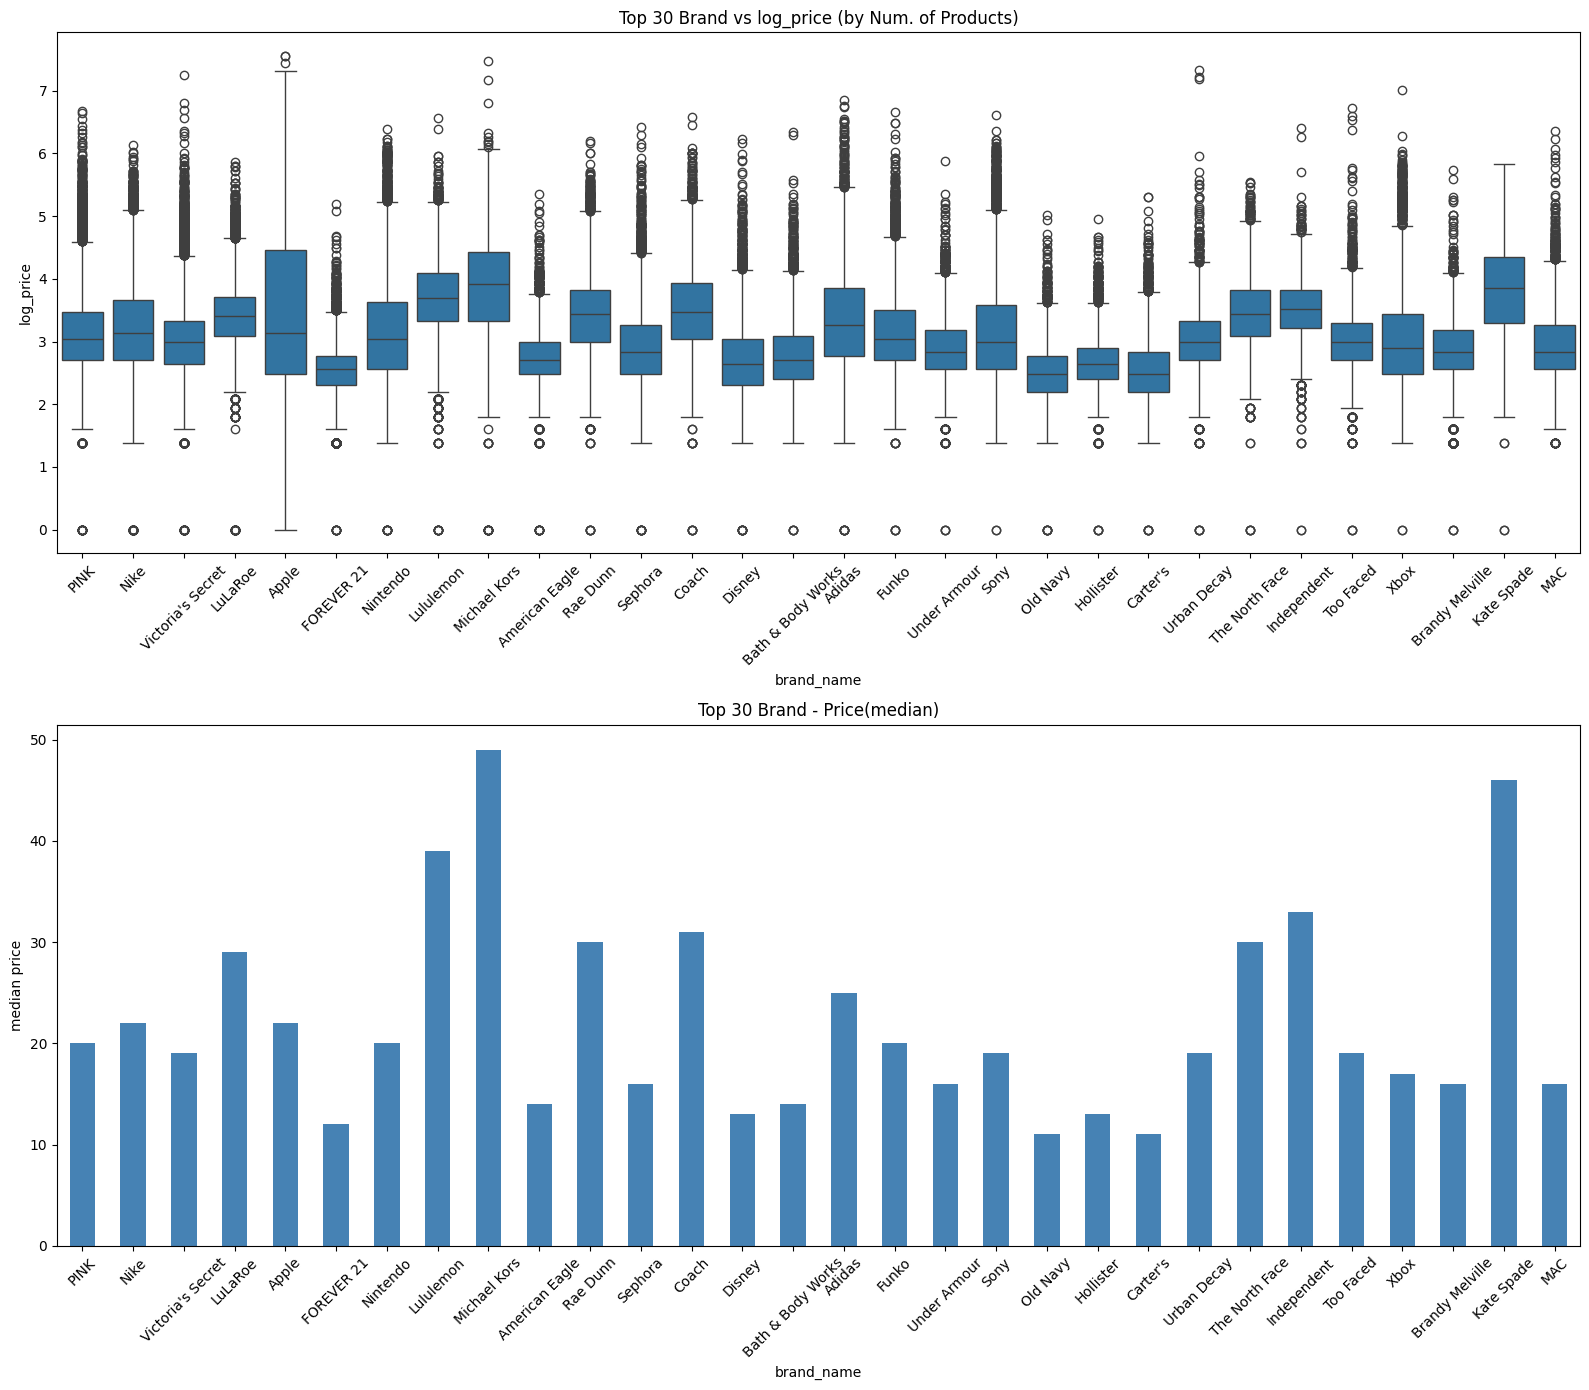

In [178]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

brand_filter = train[train['brand_name'].isin(top_brands)]

# 브랜드별 log_price 박스플롯
sns.boxplot(x='brand_name', y='log_price', 
            data=brand_filter,
            order=top_brands,
            ax=axes[0])
axes[0].set_title('Top 30 Brand vs log_price (by Num. of Products)')
axes[0].tick_params(axis='x', rotation=45)

# 브랜드별 중앙값 barplot
brand_median = brand_filter.groupby('brand_name')['price']\
                .median().reindex(top_brands)
brand_median.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 30 Brand - Price(median)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('median price')

plt.tight_layout()
plt.show()

**💡[Insights]**  
- 상품수 기준 Top 30 Brand의 가격 분포   
  : 거래가 활발한 브랜드의 가격대를 확인할 수 있다.   
    1. 'Michael Kors'와 'Kate Spade'에서 압도적으로 높은 중앙값을 나타낸다. 중고가의 명품 브랜드 상품이 거래량의 상위권에 있음을 확인할 수 있다.   
    2. 'Lululemon', 'Independent', 'Coach', 'The North Face'가 뒤이어 나타난다. 프리미엄 스포츠 브랜드, 중고가 명품브랜드임을 일관되게 확인할 수 있다.  
    3. 대표적인 저가 브랜드로 'Forever 21', 'Old Navy', "Carter's", 'American Eagle'이 하위권으로 대표적인 저가브랜드의 특성을 확인할 수 있다. 
    4. Boxplot의 형태에 있어, 'Apple'의 경우, 다른 브랜드보다 IQR의 크기가 큰 것을 확인할 수 있다. 저가 악세사리부터 고가 기기까지 가격대가 넓게 분포되어 있음을 확인할 수 있다.   
       => 추가적으로 cat_2와 cat_3에 대한 분석이 필요하다.


In [179]:
# 중앙값 기준 상위 30개 브랜드 (샘플 수 50개 이상 필터링)
brand_counts = train['brand_name'].value_counts()
valid_brands = brand_counts[brand_counts >= 50].index

top_price_brands = train[train['brand_name'].isin(valid_brands)]\
                    .groupby('brand_name')['price']\
                    .median().sort_values(ascending=False).head(30).index

print("=== 가격 기준 Top 30 브랜드 가격 통계 ===")
print(train[train['brand_name'].isin(top_price_brands)]\
    .groupby('brand_name')['price']\
    .agg(['count', 'median', 'mean', 'min', 'max'])\
    .sort_values('median', ascending=False)\
    .round(2))

=== 가격 기준 Top 30 브랜드 가격 통계 ===
                     count  median    mean   min     max
brand_name                                              
David Yurman           242   220.0  248.61   7.0  2004.0
Balenciaga              63   176.0  185.44  14.0   959.0
Christian Louboutin    360   156.0  188.44   9.0   650.0
Tieks                   61   156.0  152.95  29.0   245.0
Sherri Hill            213   151.0  169.66   5.0   999.0
Celine                  73   149.0  238.78  12.0  1806.0
Jovani                  71   139.0  164.76   0.0   456.0
MICHELE                 59   134.0  216.98  10.0   906.0
Go Gear                 92   132.5  150.17  10.0   610.0
MCM Worldwide           69   129.0  289.17  11.0  1359.0
Stuart Weitzman         60   128.5  198.72   5.0   679.0
Spin Master            549   110.0   97.65   3.0   765.0
Yeezy                  170   107.5  137.76   0.0   634.0
Rolex                   89   106.0  134.64  19.0   980.0
Valentino               96   106.0  191.08  11.0   909.0


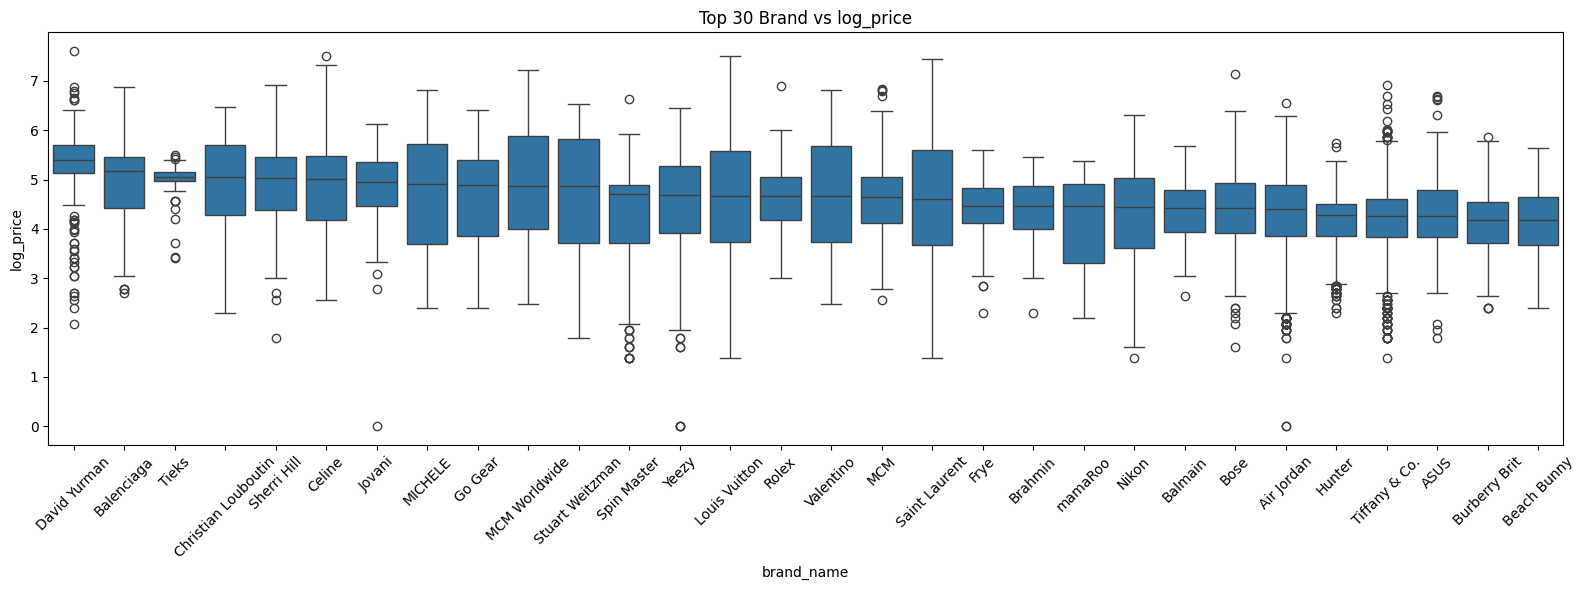

In [180]:
# 중앙값 기준 상위 30개 브랜드 박스플롯

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(x='brand_name', y='log_price',
            data=train[train['brand_name'].isin(top_price_brands)],
            order=top_price_brands,
            ax=ax)
ax.set_title('Top 30 Brand vs log_price')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**💡[Insights]**  
- 가격(중앙값) 기준 Top 30 Brand 분석   
  : 고가 브랜드의 존재 여부 및 가격 범위를 확인할 수 있다.   
    1. 'David Yurman'와 'Balenciaga','Tieks','Christian Louboutin'과 같이 고가 명품브랜드를 확인할 수 있다. Mercari 중고거래사이트에서도 고가 거래가 이루어짐을 확인할 수 있다.  
    2. 'Louis Vuitton', 'Rolex', 'Saint Laurant', 'Tiffany & Co.'와 같이 글로벌 럭셔리 브랜드와 함께 'Air Jordan'과 같이 한정판 스니커즈 브랜드도 포함되어 있어 리셀 시장의 특성도 확인해 볼 수 있다.    
    3. 'Louis Vuitton'은 가격기준 상위 Top 브랜드에 속하면서도, 3,187개의 상품수를 확인할 수 있다. 럭셔리 브랜드이면서 거래량이 많은 것을 확인할 수 있다.    
    4. 'Nikon', 'Bose', 'ASUS'와 같이 전자기기와 카메라 브랜드도 포함되어, Electronics 카테고리에도 고가 브랜드가 포함되어 있음을 확인할 수 있다.  
        (앞서 Electronics 카테고리의 중앙값이 15였으나, 수염이 위로 뻗어있어 고가의 상품이 존재함을 확인한 것과 일치한다.)   
    

3-2-2-3. 'name'과 'item_description' 컬럼의 길이와 price와의 상관관계

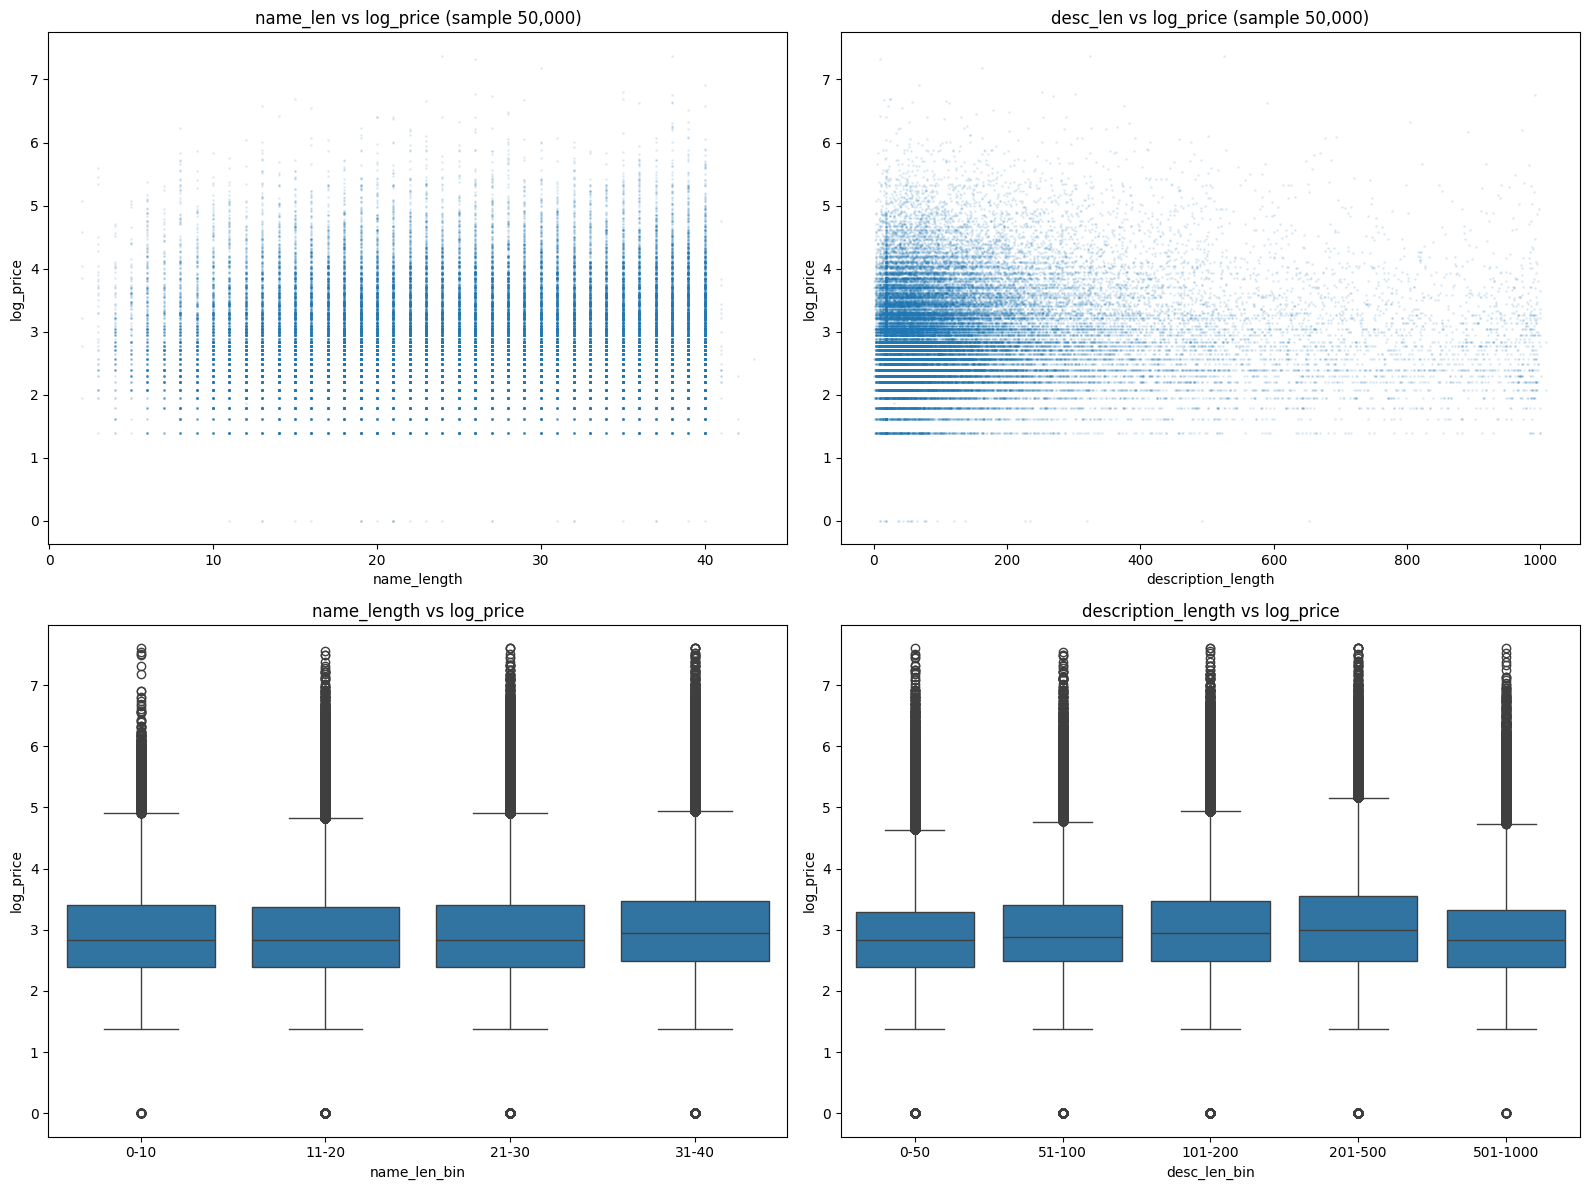

=== name_length 구간별 price 통계 ===
               count  median   mean
name_len_bin                       
0-10           70843    16.0  27.01
11-20         396337    16.0  25.51
21-30         491192    16.0  26.08
31-40         523345    18.0  28.26

=== description_length 구간별 price 통계 ===
               count  median   mean
desc_len_bin                       
0-50          470785    16.0  23.33
51-100        360650    17.0  25.80
101-200       339153    18.0  28.51
201-500       232173    19.0  32.09
501-1000       79697    16.0  27.98

=== 상관계수 ===
           name_len  desc_len  log_price
name_len     1.0000    0.2495     0.0467
desc_len     0.2495    1.0000     0.0302
log_price    0.0467    0.0302     1.0000


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\1128865003.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.groupby('name_len_bin')['price'].agg(['count','median','mean']).round(2))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\1128865003.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.groupby('desc_len_bin')['price'].agg(['count','median','mean']).round(2))


In [181]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. name_len x log_price 산점도 : 데이터 샘플링 후 시각확

sample = train.sample(n=50000, random_state=42)
axes[0][0].scatter(sample['name_len'], sample['log_price'], alpha=0.1, s=1)
axes[0][0].set_title('name_len vs log_price (sample 50,000)')
axes[0][0].set_xlabel('name_length')
axes[0][0].set_ylabel('log_price')

# 2. desc_len x log_price 산점도
axes[0][1].scatter(sample['desc_len'], sample['log_price'], alpha=0.1, s=1)
axes[0][1].set_title('desc_len vs log_price (sample 50,000)')
axes[0][1].set_xlabel('description_length')
axes[0][1].set_ylabel('log_price')

# 3. name_len 구간화 후 boxplot
train['name_len_bin'] = pd.cut(train['name_len'], 
                                bins=[0, 10, 20, 30, 40],
                                labels=['0-10', '11-20', '21-30', '31-40'])
sns.boxplot(x='name_len_bin', y='log_price', data=train, ax=axes[1][0])
axes[1][0].set_title('name_length vs log_price')
axes[1][0].set_xlabel('name_len_bin')

# 4. desc_len 구간화 후 boxplot
train['desc_len_bin'] = pd.cut(train['desc_len'],
                                bins=[0, 50, 100, 200, 500, 1000],
                                labels=['0-50', '51-100', '101-200', '201-500', '501-1000'])
sns.boxplot(x='desc_len_bin', y='log_price', data=train, ax=axes[1][1])
axes[1][1].set_title('description_length vs log_price')
axes[1][1].set_xlabel('desc_len_bin')

plt.tight_layout()
plt.show()

# 수치 확인
print("=== name_length 구간별 price 통계 ===")
print(train.groupby('name_len_bin')['price'].agg(['count','median','mean']).round(2))

print("\n=== description_length 구간별 price 통계 ===")
print(train.groupby('desc_len_bin')['price'].agg(['count','median','mean']).round(2))

# 상관계수 확인
print("\n=== 상관계수 ===")
print(train[['name_len', 'desc_len', 'log_price']].corr().round(4))

**💡[Insights]**  
- 'name'과 'item_description' 컬럼의 길이와 가격의 상관관계 분석   
    1. 'name' 길이 : 모든 구간에서 가격이 고르게 분포해 있으며, 상관계수도 0.0467로 설명길이와 가격 간의 선형관계가 거의 없다.
    2. 'item_description' 길이 :   
      - 설명이 증가한다고 해서 가격 분포에 영향을 주지 않음을 확인할 수 있다. (산점도에서 상품 설명 길이가 증가할 수록 가격 분포는 크게 변하지 않는 것을 확인할 수 있다.)   
      - 구간별 중앙값에서 설명이 길수록 중앙값이 약간 높은 경향이 있지만, 중앙값의 최소 16과 최대 19의 차이가 크지 않은 것을 확인할 수 있다.   
      - 상관계수가 0.0302로 상품 설명의 길이는 가격과 거의 관계가 없음을 확인할 수 있다.  

---
#### 3-3. 'Women'과 'Beauty' 카테고리에 대한 추가 분석   
'Women'과 'Beauty' 카테고리에 속하는 상품의 수는 총 872,213개로 전체 상품수의 58.83%를 차지한다.   
이는 Mercari의 핵심 카테고리임이며, 해당 사이트의 주요 고객이 여성임을 확인할 수 있다.  
해당 카테고리 분석을 통하여 '여성 중고시장 분석'을 진행하도록 하겠다. 

In [182]:
# Women, Beauty 필터링
women = train[train['cat_1'] == 'Women'].copy()
beauty = train[train['cat_1'] == 'Beauty'].copy()

# 기본 현황
print("=== 기본 현황 ===")
print(f"Women 상품 수: {len(women):,}개 (전체의 {len(women)/len(train)*100:.2f}%)")
print(f"Beauty 상품 수: {len(beauty):,}개 (전체의 {len(beauty)/len(train)*100:.2f}%)")
print(f"Women + Beauty 합계: {len(women)+len(beauty):,}개 (전체의 {(len(women)+len(beauty))/len(train)*100:.2f}%)")

=== 기본 현황 ===
Women 상품 수: 664,385개 (전체의 44.81%)
Beauty 상품 수: 207,828개 (전체의 14.02%)
Women + Beauty 합계: 872,213개 (전체의 58.83%)


##### 3-3-1. 'item_condition_id', 'shipping' 

In [183]:
# 'Women' 카테고리 상품 컨디션별 상품 수 및 분포 비율

print("\n=== Women - item_condition_id 분포 ===")
print(women['item_condition_id'].value_counts().sort_index())
print(f"\n비율:\n{(women['item_condition_id'].value_counts(normalize=True).sort_index()*100).round(2)}")


=== Women - item_condition_id 분포 ===
item_condition_id
1    228077
2    206217
3    215307
4     14289
5       495
Name: count, dtype: int64

비율:
item_condition_id
1    34.33
2    31.04
3    32.41
4     2.15
5     0.07
Name: proportion, dtype: float64


In [184]:
# 'Beauty' 카테고리 상품 컨디션별 상품 수 및 분포 비율

print("\n=== Beauty - item_condition_id 분포 ===")
print(beauty['item_condition_id'].value_counts().sort_index())
print(f"\n비율:\n{(beauty['item_condition_id'].value_counts(normalize=True).sort_index()*100).round(2)}")


=== Beauty - item_condition_id 분포 ===
item_condition_id
1    149964
2     30454
3     25675
4      1676
5        59
Name: count, dtype: int64

비율:
item_condition_id
1    72.16
2    14.65
3    12.35
4     0.81
5     0.03
Name: proportion, dtype: float64


In [185]:
# 'Women' 카테고리 상품의 배송비 부담여부에 따른 상품 수 및 분포 비율

print("\n=== Women - shipping 분포 ===")
print(women['shipping'].value_counts().sort_index())
print(f"\n비율:\n{(women['shipping'].value_counts(normalize=True).sort_index()*100).round(2)}")


=== Women - shipping 분포 ===
shipping
0    404087
1    260298
Name: count, dtype: int64

비율:
shipping
0    60.82
1    39.18
Name: proportion, dtype: float64


In [186]:
# 'Beauty' 카테고리 상품의 배송비 부담여부에 따른 상품 수 및 분포 비율
print("\n=== Beauty - shipping 분포 ===")
print(beauty['shipping'].value_counts().sort_index())
print(f"\n비율:\n{(beauty['shipping'].value_counts(normalize=True).sort_index()*100).round(2)}")


=== Beauty - shipping 분포 ===
shipping
0     81125
1    126703
Name: count, dtype: int64

비율:
shipping
0    39.03
1    60.97
Name: proportion, dtype: float64


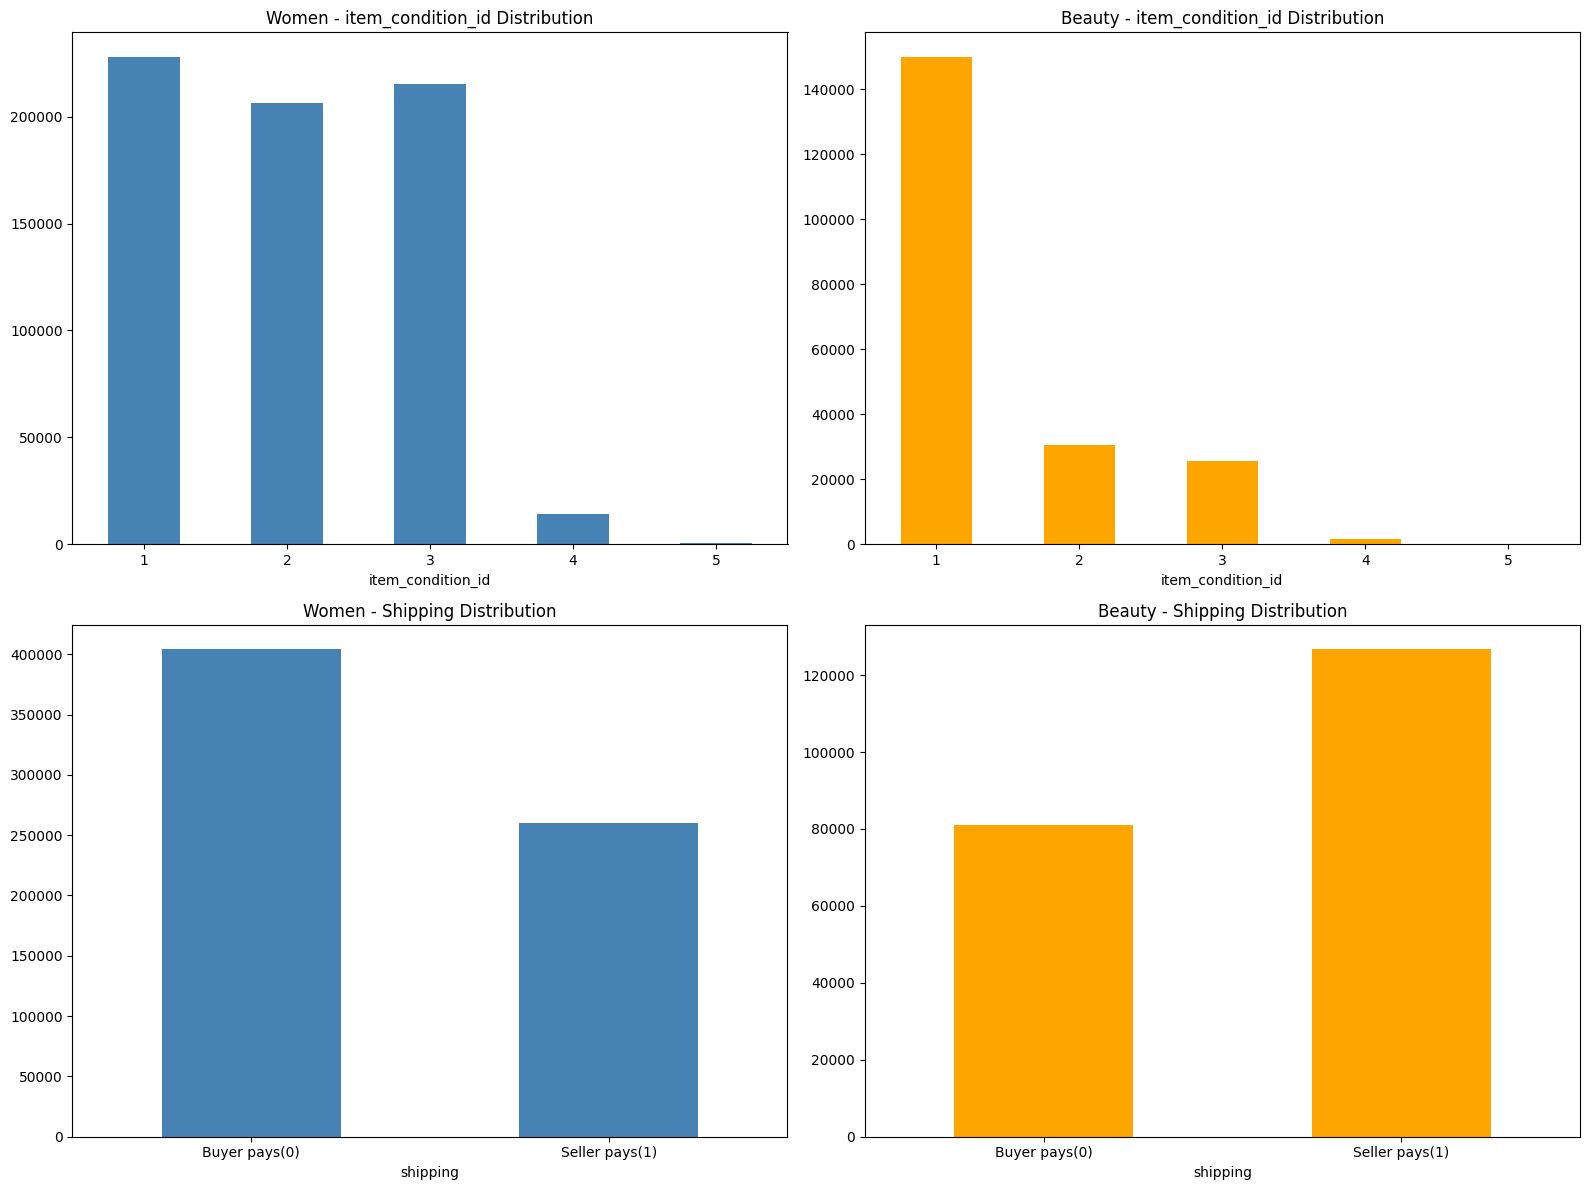

In [187]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# item_condition_id 분포 비교
women['item_condition_id'].value_counts().sort_index()\
    .plot(kind='bar', ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Women - item_condition_id Distribution')
axes[0][0].tick_params(axis='x', rotation=0)

beauty['item_condition_id'].value_counts().sort_index()\
    .plot(kind='bar', ax=axes[0][1], color='orange')
axes[0][1].set_title('Beauty - item_condition_id Distribution')
axes[0][1].tick_params(axis='x', rotation=0)

# shipping 분포 비교
women['shipping'].value_counts().sort_index()\
    .plot(kind='bar', ax=axes[1][0], color='steelblue')
axes[1][0].set_title('Women - Shipping Distribution')
axes[1][0].set_xticklabels(['Buyer pays(0)', 'Seller pays(1)'], rotation=0)

beauty['shipping'].value_counts().sort_index()\
    .plot(kind='bar', ax=axes[1][1], color='orange')
axes[1][1].set_title('Beauty - Shipping Distribution')
axes[1][1].set_xticklabels(['Buyer pays(0)', 'Seller pays(1)'], rotation=0)

plt.tight_layout()
plt.show()

**💡[Insights]**  
1. 'item_condotion_id (상품 상태)' :  
    - Women : 1 ~ 3 등급에 상품이 고른 분포를 확인할 수 있다. 다양한 컨디션의 상품이 거래되고 있음을 나타낸다.   
    - Beauty : 1등급 상품에 149,964개(72.16%)의 상품이 집중되어 있다. "새 상품" 위주로 거래가 이루어지고 있음을 추정할 수 있다.   
    
2. 'shipping (배송비 부담)' :   
    - Women : 구매자가 배송비를 부담하는 경우가 더 밚다. (전체 데이터의 패턴과 일치한다.)  
    - Beauty : 판매자가 배송비를 부담하는 양상이 높다. (전체 데이터의 패턴과 반대의 모습을 보인다.)  
               Beauty 카테고리 상품의 경우, 배송비(shipping)를 판매자가 부담함으로써 판매 전략으로 사용됨을 추정할 수 있다. 

##### 3-3-2. 'price' 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\3453306947.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2][0].set_xticklabels(['Buyer pays(0)', 'Seller pays(1)'])
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\3453306947.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2][1].set_xticklabels(['Buyer pays(0)', 'Seller pays(1)'])


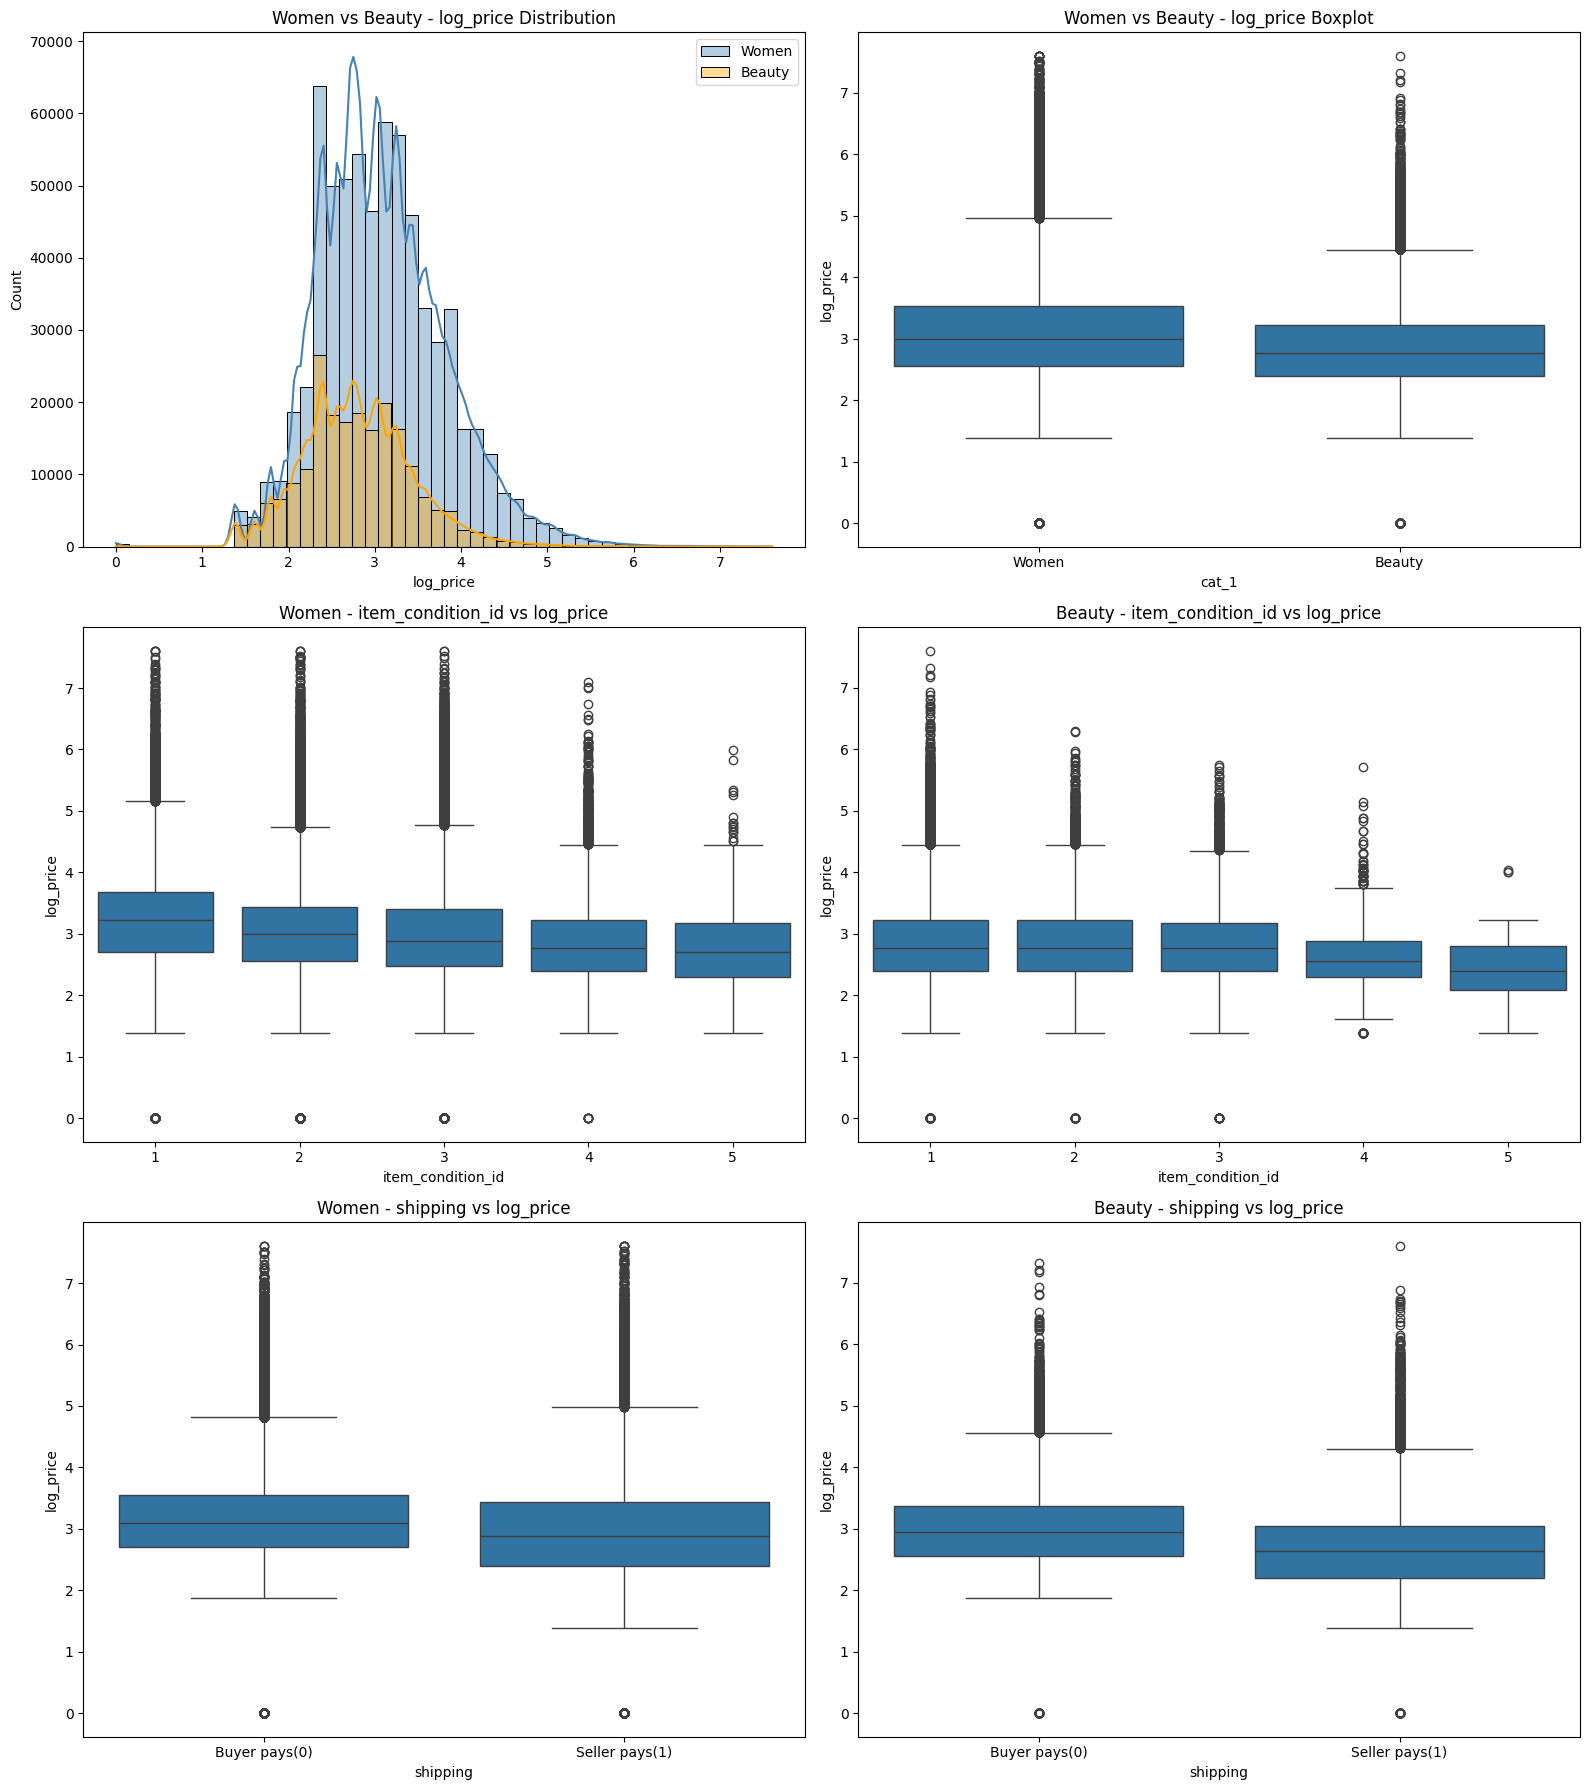

In [189]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Women vs Beauty price 분포 비교 (histplot + kde)
sns.histplot(women['log_price'], bins=50, kde=True, 
             color='steelblue', alpha=0.4, label='Women', ax=axes[0][0])
sns.histplot(beauty['log_price'], bins=50, kde=True, 
             color='orange', alpha=0.4, label='Beauty', ax=axes[0][0])
axes[0][0].set_title('Women vs Beauty - log_price Distribution')
axes[0][0].legend()

# 2. Women vs Beauty boxplot
sns.boxplot(x='cat_1', y='log_price', 
            data=train[train['cat_1'].isin(['Women','Beauty'])],
            ax=axes[0][1])
axes[0][1].set_title('Women vs Beauty - log_price Boxplot')

# 3. Women - item_condition_id x log_price
sns.boxplot(x='item_condition_id', y='log_price', data=women, ax=axes[1][0])
axes[1][0].set_title('Women - item_condition_id vs log_price')

# 4. Beauty - item_condition_id x log_price
sns.boxplot(x='item_condition_id', y='log_price', data=beauty, ax=axes[1][1])
axes[1][1].set_title('Beauty - item_condition_id vs log_price')

# 5. Women - shipping x log_price
sns.boxplot(x='shipping', y='log_price', data=women, ax=axes[2][0])
axes[2][0].set_title('Women - shipping vs log_price')
axes[2][0].set_xticklabels(['Buyer pays(0)', 'Seller pays(1)'])

# 6. Beauty - shipping x log_price
sns.boxplot(x='shipping', y='log_price', data=beauty, ax=axes[2][1])
axes[2][1].set_title('Beauty - shipping vs log_price')
axes[2][1].set_xticklabels(['Buyer pays(0)', 'Seller pays(1)'])

plt.tight_layout()
plt.show()

In [190]:
# 수치 확인
print("=== Women vs Beauty price 통계 요약 ===")
print(train[train['cat_1'].isin(['Women','Beauty'])]\
    .groupby('cat_1')['price']\
    .agg(['count','median','mean','min','max']).round(2))


=== Women vs Beauty price 통계 요약 ===
         count  median   mean  min     max
cat_1                                     
Beauty  207828    15.0  19.67  0.0  2000.0
Women   664385    19.0  28.89  0.0  2009.0


In [194]:
# 상품 컨디션에 따른 가격과의 관계 ("Women", "Beauty" 카테고리 수치 확인)

print("\n=== Women - 상품 컨디션 등급별 price(중앙값) 비교 ===")
print(women.groupby('item_condition_id')['price'].agg(['count','median','mean']).round(2))

print("\n=== Beauty - 상품 컨디션 등급별 price(중앙값) 비교 ===")
print(beauty.groupby('item_condition_id')['price'].agg(['count','median','mean']).round(2))



=== Women - 상품 컨디션 등급별 price(중앙값) 비교 ===
                    count  median   mean
item_condition_id                       
1                  228077    24.0  32.75
2                  206217    19.0  27.57
3                  215307    17.0  26.49
4                   14289    15.0  22.46
5                     495    14.0  22.55

=== Beauty - 상품 컨디션 등급별 price(중앙값) 비교 ===
                    count  median   mean
item_condition_id                       
1                  149964    15.0  19.81
2                   30454    15.0  19.59
3                   25675    15.0  19.28
4                    1676    12.0  15.04
5                      59    10.0  13.08


In [195]:
# 배송비 부담과 가격과의 관계 ("Women", "Beauty" 카테고리 수치 확인)

print("\n=== Women - 배송비 부담에 따른 price(중앙값) 비교 ===")
print(women.groupby('shipping')['price'].agg(['count','median','mean']).round(2))

print("\n=== Beauty - 배송비 부담에 따른 price(중앙값) 비교 ===")
print(beauty.groupby('shipping')['price'].agg(['count','median','mean']).round(2))


=== Women - 배송비 부담에 따른 price(중앙값) 비교 ===
           count  median   mean
shipping                       
0         404087    21.0  30.63
1         260298    17.0  26.18

=== Beauty - 배송비 부담에 따른 price(중앙값) 비교 ===
           count  median   mean
shipping                       
0          81125    18.0  23.73
1         126703    13.0  17.08


---
**💡[Insights]**  
1. 'item_condotion_id (상품 상태)'와 price(가격)과의 관계 분석 :  
    - Women : 1 등급(중앙값 24)에서 5 등급(중앙값 22)으로 갈수록 완만하게 가격이 낮아지는 것을 확인할 수 있다.   
              평균값과 중앙값의 차이가 Beauty 카테고리 상품에 비해 크다. Women 카테고리 항목에 고가의 상품이 더 많이 존재함을 추정할 수 있다.  
    - Beauty : 1등급(중앙값 15)에서 5등급(중앙값 10)으로 갈수록 'Women' 카테코리에 비해 가파르게 감소한다. 이는 Beauty 상품이 1등급에 집중되어 있는 것과 관계있으며, 컨디션 상태가 가격에 더 직접적인 영향을 미치고 있음을 확인할 수 있다.  
    
2. 'shipping (배송비 부담)'과 price(가격)과의 관계 분석   
    : 'Women'과 'Beauty' 카테고리 모두 구매자가 배송비를 부담하는 경우(0), 중앙값이 높다.     
    - Women : 구매자 부담 중앙값(21) - 판매자부담 중앙값(17)  
    - Beauty : 구매자 부담 중앙값(18) - 판매자부담 중앙값(13)  
               Beauty 카테고리 상품의 경우, 판매자가 배송비(shipping)를 포함하여 가격을 낮게 책정하는 경향을 확인할 수 있다. 

In [208]:
# 1. Beauty 쌍봉 원인 확인 - cat_2별 가격 분포
print("\n=== Beauty 중분류(cat_2)에 따른 price 중앙값 Top 7 ===")
print(beauty.groupby('cat_2')['price']\
    .agg(['count','median','mean'])\
    .sort_values('median', ascending=False)\
    .head(10).round(2))


=== Beauty 중분류(cat_2)에 따른 price 중앙값 Top 7 ===
                      count  median   mean
cat_2                                     
Fragrance             24294    18.0  23.80
Bath & Body            7758    15.0  19.08
Hair Care              7770    15.0  19.37
Makeup               124624    15.0  18.69
Other                   489    14.0  22.95
Skin Care             29838    14.0  20.50
Tools & Accessories   13055    14.0  19.91


In [203]:
# 2. Beauty의 긴 꼬리 확인 - 고가 상품이 어떤 상품인지
print("=== Beauty 고가 상품 (100달러 이상) ===")
beauty_high = beauty[beauty['price'] >= 100]
print(f"100달러 이상 Beauty 상품 수: {len(beauty_high):,}개")
print(f"전체 Beauty 대비 비율: {len(beauty_high)/len(beauty)*100:.2f}%")

print("\n카테고리 분포:")
print(beauty_high['cat_2'].value_counts().head(10))
print("\n브랜드 분포:")
print(beauty_high['brand_name'].value_counts().head(10))

=== Beauty 고가 상품 (100달러 이상) ===
100달러 이상 Beauty 상품 수: 1,771개
전체 Beauty 대비 비율: 0.85%

카테고리 분포:
cat_2
Makeup                 726
Skin Care              477
Fragrance              258
Tools & Accessories    192
Bath & Body             57
Hair Care               46
Other                   15
Name: count, dtype: int64

브랜드 분포:
brand_name
No Brand             1028
Sephora               139
SeneGence              91
Victoria's Secret      55
MAC                    51
Urban Decay            40
Chanel                 39
Bath & Body Works      36
Too Faced              35
Mary Kay               29
Name: count, dtype: int64


In [209]:
# 3. Women 쌍봉 원인 확인 - cat_2별 가격 분포
print("\n=== Women 중분류(cat_2)에 따른 price 중앙값 Top 10 ===")
print(women.groupby('cat_2')['price']\
    .agg(['count','median','mean'])\
    .sort_values('median', ascending=False)\
    .head(10).round(2))


=== Women 중분류(cat_2)에 따른 price 중앙값 Top 10 ===
                      count  median   mean
cat_2                                     
Women's Handbags      45862    31.0  58.20
Shoes                 77654    26.0  35.98
Coats & Jackets       15087    25.0  34.04
Athletic Apparel     123457    22.0  28.84
Dresses               45758    20.0  29.45
Jeans                 32338    20.0  25.89
Sweaters              34312    20.0  26.50
Skirts                10625    18.0  21.55
Women's Accessories   42350    18.0  30.93
Other                  7264    17.0  26.01


In [205]:
# 4. Women 고가 이상치 확인
print("\n=== Women 고가 상품 (200달러 이상) ===")
women_high = women[women['price'] >= 200]
print(f"200달러 이상 Women 상품 수: {len(women_high):,}개")
print("\n카테고리 분포:")
print(women_high['cat_2'].value_counts().head(10))



=== Women 고가 상품 (200달러 이상) ===
200달러 이상 Women 상품 수: 4,325개

카테고리 분포:
cat_2
Women's Handbags       1784
Jewelry                 770
Women's Accessories     522
Shoes                   500
Dresses                 239
Athletic Apparel        203
Coats & Jackets          86
Tops & Blouses           62
Sweaters                 49
Other                    44
Name: count, dtype: int64


In [201]:
print("\n브랜드 분포:")
print(women_high['brand_name'].value_counts().head(10))


브랜드 분포:
brand_name
No Brand               836
Louis Vuitton          781
Michael Kors           219
Tory Burch             196
David Yurman           157
Gucci                  136
Christian Louboutin    134
Chanel                 132
PINK                   125
Kendra Scott           125
Name: count, dtype: int64


---
**💡[Insights]**  
1. 'Women'카테고리 분석 :  
    1) 상품 카테고리 중분류(cat_2)에 따른 가격 분포   
       - Women's Handbags(중앙값31, 평균58.2) 카테고리가 가장 높다. 중앙값과 평균의 차이가 큰 것으로 고가 명품 핸드백(이상치)로 인하여 평균이 크게 오른 것으로 추정할 수 있다.   
       - Women 카테고리의 가격 분포에 있어 쌍봉의 형태를 확인했었다.   
         Women's Handbags, Shoes, Coats & Jackets의 비교적 높은 가격의 상품군과 Skirts, Women's Accessories와 같이 낮은 가격의 상품군의 분포를 확인할 수 있다.   
    2) 고가 상품(200 이상) 분석   
       - Women 카테고리의 0.65% (Women 카테고리 상품 664,385건 중 4,325개)  
       - Women's Handbags 의 상품이 1,784개로 200 이상의 고가 상품 중 41.2%를 차지한다.   
       - 고가 상품의 브랜드 분포에 있어서, 'No Brand' 항목이 높다는 것은 브랜드가 미기재된 명품일 가능성이 높다.  

2. 'Beauty' 카테고리 분석 :  
    1) 상품 카테고리 중분류(cat_2)에 따른 가격 분포   
       - Fragrance (중앙값 18) 카테고리가 가장 높다.향수 특성상 단가가 높은 것이 반영되었다고 볼 수 있다.    
       - Makeup 제품의 경우, 상품의 수량은 압도적으로 많지만 중앙값이 15로 낮은 편이다. 거래량과 가격이 반비례하는 패턴을 확인할 수 있다.   
       - 전반적으로 중앙값이 14~18으로 가격차이가 크지 않다.
    2) 고가 상품(100 이상) 분석   
       - 전체 Beauty 카테고리의 0.85% (Beauty 카테고리 상품 207,828건 중 1,771개)  
       - 고가의 Beauty 상품 중 No Brand가 1,028개으로 브랜드가 미기재되었거나, 한정판 제품일 가능성이 높다.    
       - Makeup과 나Skin Care 항목에서 고가 상품이 많이 나타난다.  

##### 3-3-3. 카테고리 중분류(cat_2)에 대한 세분화 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\2094362163.py:26: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\2094362163.py:26: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\2094362163.py:26: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\2094362163.py:26: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\2094362163.py:26: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\berga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:

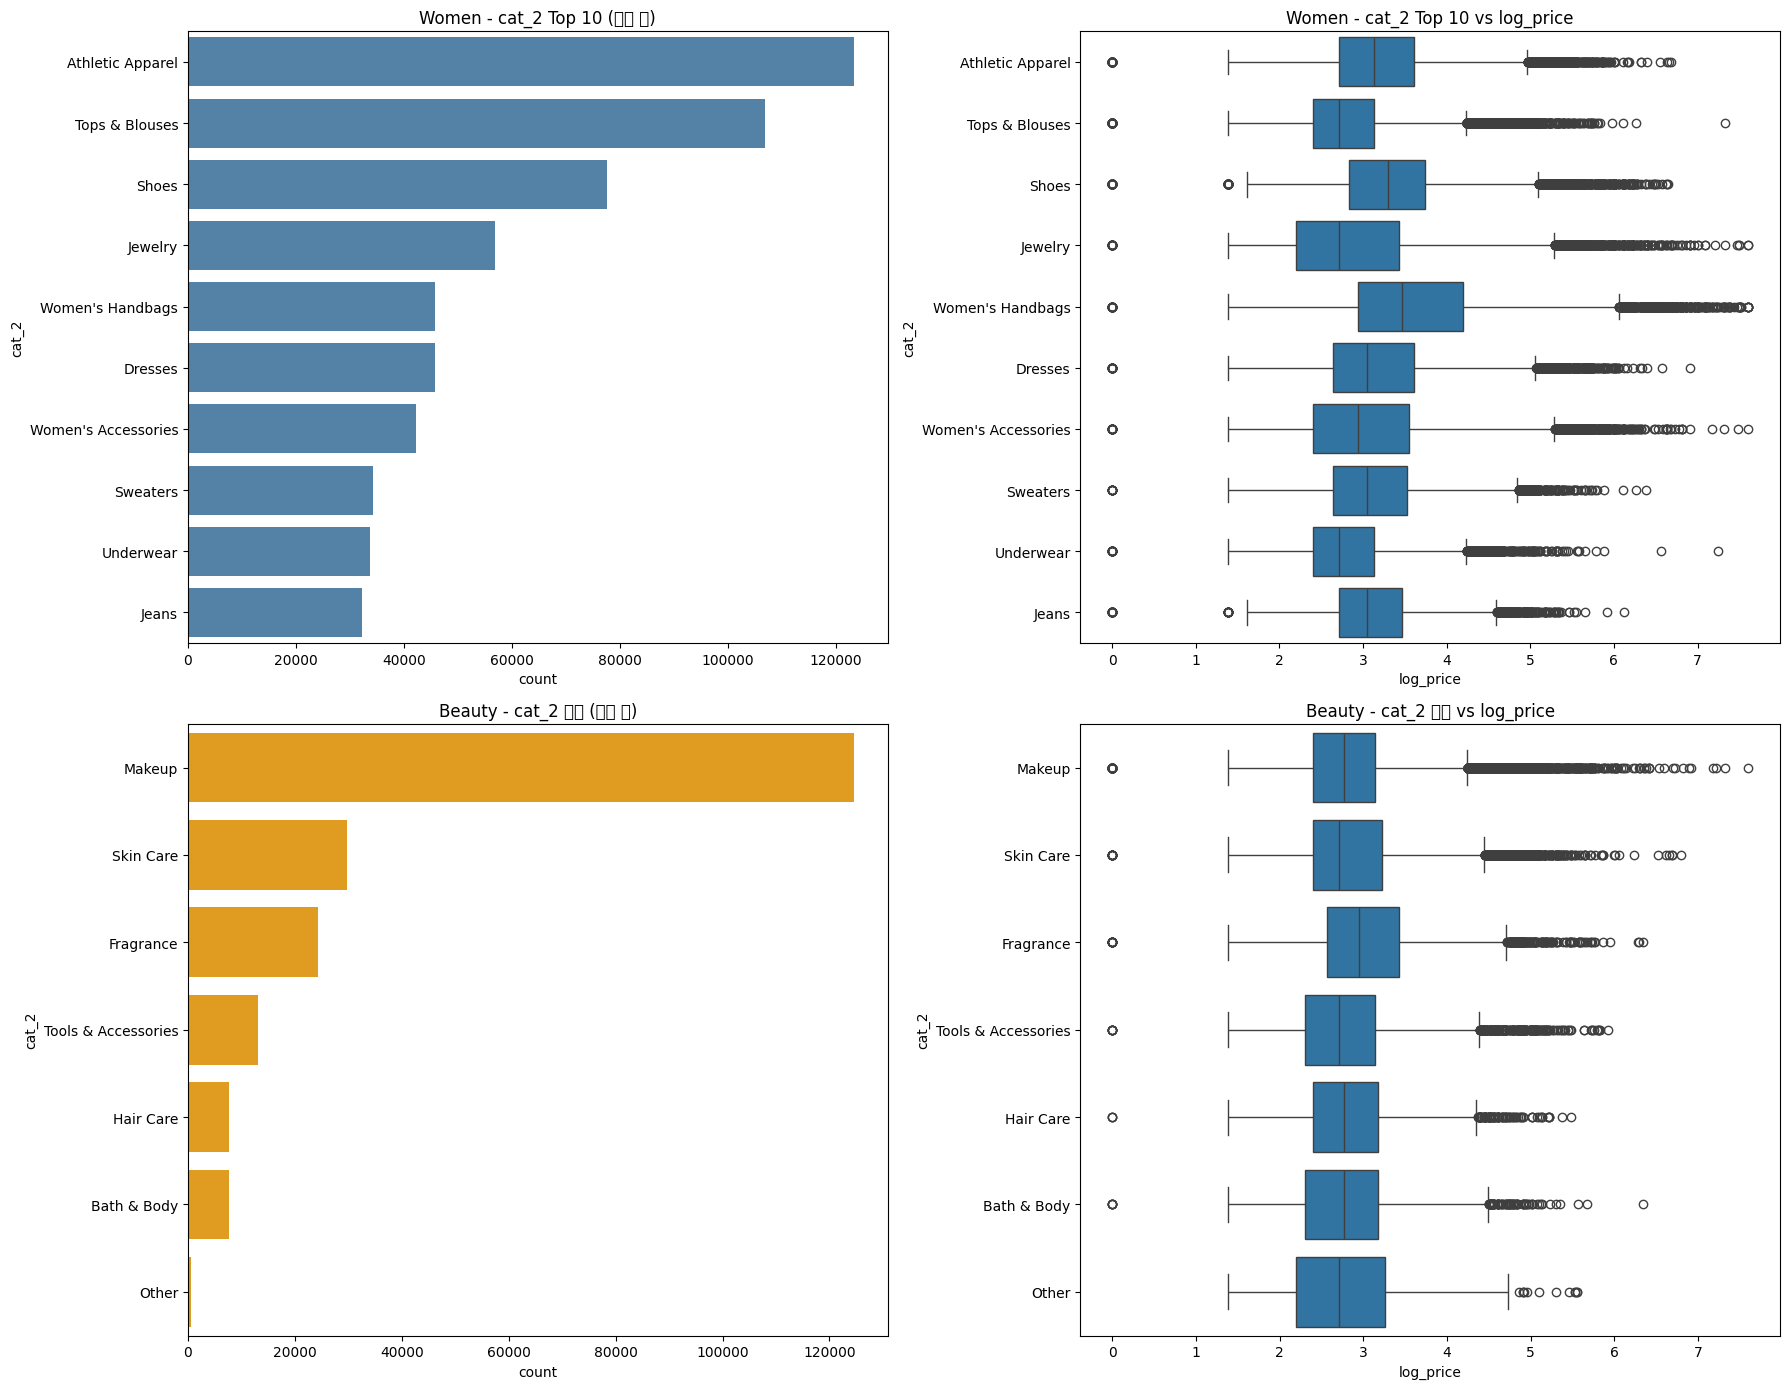

In [210]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Women cat_2 Top 10 상품 수
women_cat2_order = women['cat_2'].value_counts().head(10).index
sns.countplot(y='cat_2', data=women[women['cat_2'].isin(women_cat2_order)],
              order=women_cat2_order, ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Women - cat_2 Top 10 (상품 수)')

# Women cat_2 Top 10 x log_price boxplot
sns.boxplot(y='cat_2', x='log_price', 
            data=women[women['cat_2'].isin(women_cat2_order)],
            order=women_cat2_order, ax=axes[0][1])
axes[0][1].set_title('Women - cat_2 Top 10 vs log_price')

# Beauty cat_2 전체 상품 수 (고유값 7개)
beauty_cat2_order = beauty['cat_2'].value_counts().index
sns.countplot(y='cat_2', data=beauty,
              order=beauty_cat2_order, ax=axes[1][0], color='orange')
axes[1][0].set_title('Beauty - cat_2 전체 (상품 수)')

# Beauty cat_2 전체 x log_price boxplot
sns.boxplot(y='cat_2', x='log_price',
            data=beauty, order=beauty_cat2_order, ax=axes[1][1])
axes[1][1].set_title('Beauty - cat_2 전체 vs log_price')

plt.tight_layout()
plt.show()


In [213]:
# 수치 확인
print("=== Women - 중분류(cat_2)에 따른 price 통계 (상품 수 Top 10) ===")
print(women[women['cat_2'].isin(women_cat2_order)]\
    .groupby('cat_2')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))

print("\n=== Beauty - 중분류(cat_2)에 따른 price 통계 (전체) ===")
print(beauty.groupby('cat_2')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))


=== Women - 중분류(cat_2)에 따른 price 통계 (상품 수 Top 10) ===
                      count  median   mean     max
cat_2                                             
Women's Handbags      45862    31.0  58.20  2009.0
Shoes                 77654    26.0  35.98   770.0
Athletic Apparel     123457    22.0  28.84   798.0
Dresses               45758    20.0  29.45   999.0
Jeans                 32338    20.0  25.89   456.0
Sweaters              34312    20.0  26.50   590.0
Women's Accessories   42350    18.0  30.93  1999.0
Jewelry               56837    14.0  28.06  2004.0
Tops & Blouses       106960    14.0  18.24  1525.0
Underwear             33784    14.0  18.10  1400.0

=== Beauty - 중분류(cat_2)에 따른 price 통계 (전체) ===
                      count  median   mean     max
cat_2                                             
Fragrance             24294    18.0  23.80   569.0
Bath & Body            7758    15.0  19.08   565.0
Hair Care              7770    15.0  19.37   239.0
Makeup               124624    1

In [212]:
# Women Handbags vs Beauty Fragrance 심화 비교
print("\n=== Women Handbags - 소분류(cat_3)에 따른 price 통계 ===")
handbags = women[women['cat_2'] == "Women's Handbags"]
print(handbags.groupby('cat_3')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).head(10).round(2))

print("\n=== Beauty Fragrance - 소분류(cat_3)에 다른 price 통계 ===")
fragrance = beauty[beauty['cat_2'] == 'Fragrance']
print(fragrance.groupby('cat_3')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))


=== Women Handbags - 소분류(cat_3)에 따른 price 통계 ===
                       count  median    mean     max
cat_3                                               
Satchel                 2333    90.0  111.62  1800.0
Hobo                     323    36.0   71.76  1480.0
Messenger & Crossbody   8926    36.0   58.93  2006.0
Shoulder Bag           15328    36.0   65.98  2009.0
Backpack Style          4551    30.0   42.21  1808.0
Totes & Shoppers        9373    28.0   58.39  1615.0
Baguette                  60    20.0   35.60   231.0
Other                   1116    20.0   36.95   906.0
Cosmetic Bags           3852    13.0   17.05   307.0

=== Beauty Fragrance - 소분류(cat_3)에 다른 price 통계 ===
                       count  median   mean    max
cat_3                                             
Men                     2114    23.0  28.56  320.0
Sets                     461    20.0  25.60  310.0
Candles & Home Scents   2965    18.0  21.09  282.0
Women                  18628    18.0  23.72  569.0
Other    

---
**💡[Insights]**  
1. 'Women' 세부 카테고리(cat_2) 분석 :  
    - Athletic Apparel(12만)과 Tops & Blouses(11만)가 상품 수 1, 2위이지만 중앙값은 22, 18로 낮다. 거래량과 가격의 반비례 패턴을 확인할 수 있다.    
    - Women's Handbags는 상품 수 5위(4.5만)이지만 중앙값 31로 가격에서 1위를 차지한다. 수량은 적지만 고가 거래가 집중되는 카테고리임을 확인할 수 있다.   
    - max값에서 Jewelry(2,004), Women's Accessories(1,999), Women's Handbags(2,009)으로 최고가격을 확인할 수 있다. 이 세 개의 카테고리가 Women의 고가 이상치를 형성함을 확인할 수 있다.  
    - boxplot에서 Women's Handbags의 whisker가 가장 길어 가격 범위가 넓음을 시각적으로 확인할 수 있다.  

    ※ Women > Women's Handbags > 소분류(cat_3) 분석  
       - Shoulder Bag(count 15,328)이 가장 많은 상품이 거래되지만, 중앙값 36으로 거래량과 가격의 반비례인 패턴이 여기서도 확인된다.  
       - Messenger & Crossbody(max 2,006), Backpack Style(max 1,800)로 최고가를 형성하고 있다.   
       - Cosmetic Bags(중앙값 13)가 최하위로, 핸드백 카테고리 내에서도 가격 양극화가 심한 것을 확인할 수 있다.


2. 'Beauty' 세부 카테고리(cat_2) 분석 :  
    - Makeup 카테고리 상품이 가장 많이 거래되고 있지만, 가격에 있어 중앙값 15로 최하위권에 속한다.  
    - Fragrance가 중앙값 18로 가격면에서 1위이고, Bath & Body(15)가 그 뒤를 이어 나타나고 있다.    
    - Other의 중앙값이 14달이지만 max가 259로, 카테고리가 분류되지 않은 특수 뷰티 상품이 고가를 형성하고 있음을 추론할 수 있다.   
      
    ※ Beauty > Fragrance > 소분류(cat_3) 분석  
       - Men 향수(중앙값 23)가 Women 향수(18)보다 높아요. 남성 향수가 여성 향수보다 단가가 높은 경향을 확인할 수 있다.   
       - Candles & Home Scents(상품수 2,965개, 중앙값 18) 가 향수 다음으로 많은 카테고리임을 확인할 수 있다.   
       - Sets(중앙값 20, max 310) 상품의 경우, 특성상 가격의 범위가 넓은 것을 확인할 수 있다.   


##### 3-3-4. 'brand_name' 결합 분석 

In [218]:
# Women, Beauty 내 No Brand 비율 확인
print("=== No Brand 비율 비교 ===")
print(f"전체 No Brand 비율: {(train['brand_name']=='No Brand').sum()/len(train)*100:.2f}%")
print(f"Women No Brand 비율: {(women['brand_name']=='No Brand').sum()/len(women)*100:.2f}%")
print(f"Beauty No Brand 비율: {(beauty['brand_name']=='No Brand').sum()/len(beauty)*100:.2f}%")

# Women 브랜드 분석
women_brand_order = women[women['brand_name'] != 'No Brand']['brand_name']\
                        .value_counts().head(20).index

print("\n=== Women - Top 20 브랜드 price 통계 ===")
print(women[women['brand_name'].isin(women_brand_order)]\
    .groupby('brand_name')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))


=== No Brand 비율 비교 ===
전체 No Brand 비율: 42.68%
Women No Brand 비율: 31.73%
Beauty No Brand 비율: 46.31%

=== Women - Top 20 브랜드 price 통계 ===
                   count  median   mean     max
brand_name                                     
Kendra Scott        5087    52.0  65.99   651.0
Michael Kors       13139    49.0  62.49  1770.0
Kate Spade          5101    47.0  59.26   340.0
Lululemon          14218    39.0  47.29   711.0
Independent         5851    33.0  36.75   604.0
The North Face      3861    31.0  37.67   256.0
Coach               9712    31.0  41.30   720.0
LuLaRoe            30764    29.0  33.68   350.0
Adidas              5235    24.0  39.70   500.0
Nike               24436    21.0  28.30   381.0
PINK               52601    20.0  26.27   798.0
Vera Bradley        3798    19.0  22.82   279.0
Victoria's Secret  39009    19.0  23.80  1400.0
Brandy Melville     5623    16.0  18.83   310.0
Under Armour        4846    16.0  18.29   167.0
American Eagle     11833    14.0  15.94   178.0


In [219]:
# Beauty 브랜드 분석
beauty_brand_order = beauty[beauty['brand_name'] != 'No Brand']['brand_name']\
                        .value_counts().head(20).index

print("\n=== Beauty - Top 20 브랜드 price 통계 ===")
print(beauty[beauty['brand_name'].isin(beauty_brand_order)]\
    .groupby('brand_name')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))


=== Beauty - Top 20 브랜드 price 통계 ===
                         count  median   mean     max
brand_name                                           
SeneGence                 4044    24.0  33.07   980.0
Younique                  1567    20.0  24.12   410.0
Kat Von D                 2011    20.0  23.87   389.0
Urban Decay               6199    19.0  22.98  1515.0
Too Faced                 5786    19.0  22.47   837.0
Tarte                     4977    19.0  22.17   609.0
Anastasia Beverly Hills   2379    19.0  22.13   173.0
Estee Lauder              1525    19.0  23.85   611.0
Kylie Cosmetics           2749    18.0  22.37   225.0
MAC                       5300    16.0  21.90   575.0
Sephora                  12159    16.0  21.83   613.0
Victoria's Secret         8635    16.0  20.57   810.0
Bath & Body Works         9050    14.0  17.17   565.0
Clinique                  1767    14.0  16.74   271.0
Ulta                      1464    14.0  18.22   309.0
Benefit                   2341    14.0  16.4

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\248668466.py:32: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\248668466.py:32: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_61036\248668466.py:32: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\berga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\berga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\berga\anaconda3\Lib\site-packag

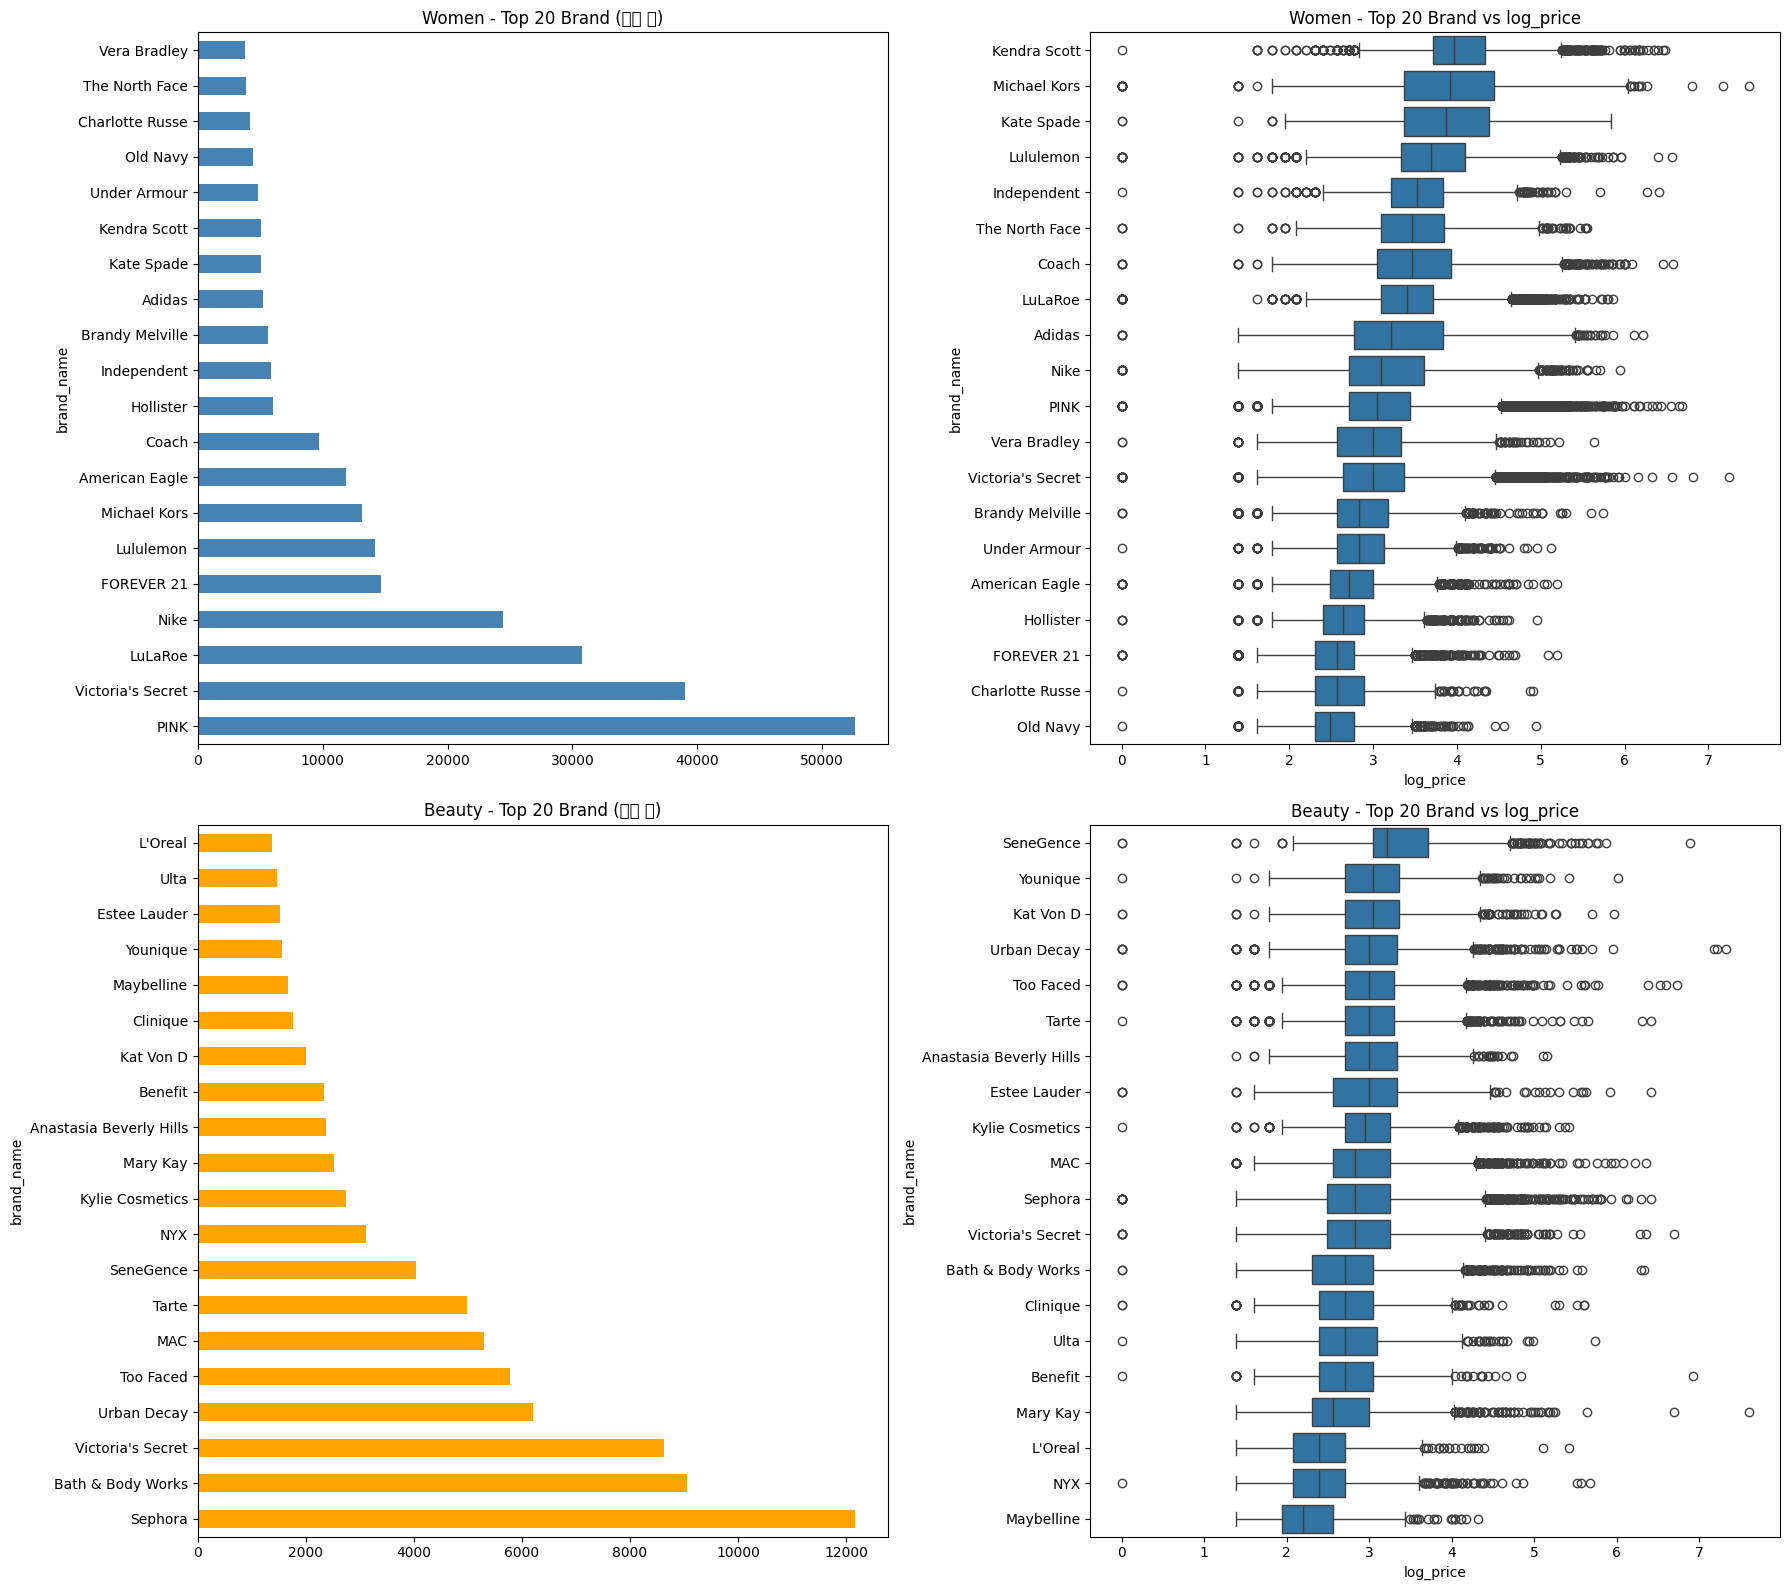

In [217]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Women Top 20 브랜드 상품 수
women[women['brand_name'].isin(women_brand_order)]['brand_name']\
    .value_counts().plot(kind='barh', ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Women - Top 20 Brand (상품 수)')

# Women Top 20 브랜드 x log_price
sns.boxplot(y='brand_name', x='log_price',
            data=women[women['brand_name'].isin(women_brand_order)],
            order=women[women['brand_name'].isin(women_brand_order)]\
                .groupby('brand_name')['price'].median()\
                .sort_values(ascending=False).index,
            ax=axes[0][1])
axes[0][1].set_title('Women - Top 20 Brand vs log_price')

# Beauty Top 20 브랜드 상품 수
beauty[beauty['brand_name'].isin(beauty_brand_order)]['brand_name']\
    .value_counts().plot(kind='barh', ax=axes[1][0], color='orange')
axes[1][0].set_title('Beauty - Top 20 Brand (상품 수)')

# Beauty Top 20 브랜드 x log_price
sns.boxplot(y='brand_name', x='log_price',
            data=beauty[beauty['brand_name'].isin(beauty_brand_order)],
            order=beauty[beauty['brand_name'].isin(beauty_brand_order)]\
                .groupby('brand_name')['price'].median()\
                .sort_values(ascending=False).index,
            ax=axes[1][1])
axes[1][1].set_title('Beauty - Top 20 Brand vs log_price')

plt.tight_layout()
plt.show()

[Women vs Beauty 브랜드 분석 정리]

Women:
- 고가 브랜드: Kendra Scott, Michael Kors, Kate Spade
  (중앙값 47달러 이상, 주얼리/핸드백 특화)
- 저가 브랜드: Old Navy, Charlotte Russe, Hollister
  (중앙값 13달러 이하)
- 거래량 상위 브랜드(PINK, Victoria's Secret)는
  저가 위주 → 브랜드 인지도 ≠ 고가

Beauty:
- 고가 브랜드: SeneGence, Younique, Kat Von D
  (직접판매/프리미엄 브랜드)
- 저가 브랜드: Maybelline, NYX, L'Oreal
  (대중 브랜드, 중앙값 8~10달러)
- Beauty는 브랜드 간 가격 차이가 Women보다 작음
  (8~24달러 범위)


##### 3-3-5. 중분류 카테고리 (cat_2)와 'brand_name' 결합 분석 

In [228]:
# Women: cat_2 x brand_name 조합 생성
women['cat2_brand'] = women['cat_2'] + ' / ' + women['brand_name']
beauty['cat2_brand'] = beauty['cat_2'] + ' / ' + beauty['brand_name']

# No Brand 제외한 조합만 분석
women_combo = women[women['brand_name'] != 'No Brand']
beauty_combo = beauty[beauty['brand_name'] != 'No Brand']

# 상품 수 기준 Top 20 조합
women_combo_order = women_combo['cat2_brand'].value_counts().head(20).index
beauty_combo_order = beauty_combo['cat2_brand'].value_counts().head(20).index

print("=== Women - 중분류 카테고리(cat_2) x brand Top 20 price 통계 (상품 수 기준) ===")
print(women_combo[women_combo['cat2_brand'].isin(women_combo_order)]\
    .groupby('cat2_brand')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))


=== Women - 중분류 카테고리(cat_2) x brand Top 20 price 통계 (상품 수 기준) ===
                                      count  median   mean     max
cat2_brand                                                        
Women's Handbags / Michael Kors        5999    76.0  84.81   900.0
Jewelry / Kendra Scott                 5075    52.0  66.05   651.0
Women's Accessories / Michael Kors     4114    42.0  53.09  1770.0
Women's Handbags / Coach               5278    40.5  52.07   720.0
Athletic Apparel / Lululemon          12237    40.0  48.41   600.0
Dresses / LuLaRoe                      5766    38.0  42.21   233.0
Shoes / Nike                           9053    36.0  42.12   381.0
Athletic Apparel / LuLaRoe             9938    27.0  31.96   350.0
Sweaters / PINK                        8785    26.0  31.07   590.0
Tops & Blouses / LuLaRoe               7417    26.0  29.44   200.0
Athletic Apparel / Victoria's Secret   7114    22.0  28.18   556.0
Athletic Apparel / PINK               15169    22.0  30.29   79

In [227]:
print("\n=== Beauty - 중분류 카테고리(cat_2) x brand Top 20 price 통계 (상품 수 기준) ===")
print(beauty_combo[beauty_combo['cat2_brand'].isin(beauty_combo_order)]\
    .groupby('cat2_brand')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))


=== Beauty - 중분류 카테고리(cat_2) x brand Top 20 price 통계 (상품 수 기준) ===
                                  count  median   mean     max
cat2_brand                                                    
Makeup / SeneGence                 3933    24.0  32.91   980.0
Makeup / Tarte                     4477    20.0  22.55   609.0
Fragrance / Sephora                1364    19.0  25.10   185.0
Makeup / Anastasia Beverly Hills   2306    19.0  22.30   173.0
Makeup / Kat Von D                 1942    19.0  23.80   389.0
Makeup / Urban Decay               6102    19.0  23.09  1515.0
Makeup / Too Faced                 5730    19.0  22.51   837.0
Fragrance / Victoria's Secret      6051    18.0  21.74   535.0
Makeup / Kylie Cosmetics           2720    18.0  22.39   225.0
Skin Care / Sephora                2325    16.0  22.34   284.0
Makeup / MAC                       5034    16.0  21.84   575.0
Fragrance / Bath & Body Works      3310    16.0  19.66   543.0
Makeup / Sephora                   7076    16.0  2

In [229]:
# 가격 기준 Top 20 조합 (샘플 수 30개 이상)
women_valid = women_combo.groupby('cat2_brand').filter(lambda x: len(x) >= 30)
beauty_valid = beauty_combo.groupby('cat2_brand').filter(lambda x: len(x) >= 30)

women_price_order = women_valid.groupby('cat2_brand')['price']\
                        .median().sort_values(ascending=False).head(20).index
beauty_price_order = beauty_valid.groupby('cat2_brand')['price']\
                        .median().sort_values(ascending=False).head(20).index

print("\n=== Women - 중분류 카테고리(cat_2) x brand Top 20 price 통계 (가격 기준) ===")
print(women_valid[women_valid['cat2_brand'].isin(women_price_order)]\
    .groupby('cat2_brand')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))


=== Women - 중분류 카테고리(cat_2) x brand Top 20 price 통계 (가격 기준) ===
                                  count  median    mean     max
cat2_brand                                                     
Women's Handbags / MCM Worldwide     35   340.0  487.51  1359.0
Jewelry / David Yurman              228   224.0  253.83  2004.0
Women's Accessories / MICHELE        54   177.0  235.26   906.0
Shoes / Christian Louboutin         303   161.0  200.41   650.0
Women's Handbags / Louis Vuitton   1374   161.0  264.33  1815.0
Shoes / Valentino                    55   156.0  226.15   770.0
Shoes / Tieks                        59   156.0  157.14   245.0
Dresses / Sherri Hill               199   154.0  173.55   999.0
Coats & Jackets / Burberry           40   146.0  178.90  1009.0
Dresses / Jovani                     70   142.5  165.39   456.0
Shoes / Stuart Weitzman              58   140.5  205.07   679.0
Women's Handbags / Frye              40   140.0  141.90   271.0
Women's Handbags / MCM               46

In [231]:
print("\n=== Beauty - 중분류 카테고리(cat_2) x brand Top 20 price 통계 (가격 기준) ===")
print(beauty_valid[beauty_valid['cat2_brand'].isin(beauty_price_order)]\
    .groupby('cat2_brand')['price']\
    .agg(['count','median','mean','max'])\
    .sort_values('median', ascending=False).round(2))


=== Beauty - 중분류 카테고리(cat_2) x brand Top 20 price 통계 (가격 기준) ===
                                 count  median   mean    max
cat2_brand                                                  
Fragrance / Chanel                 660    45.0  47.47  290.0
Skin Care / SeneGence              106    39.0  38.51  150.0
Makeup / Tom Ford                   57    36.0  44.21  204.0
Skin Care / Chanel                  63    30.0  35.14  119.0
Fragrance / Georgio Armani         260    29.0  32.24  240.0
Fragrance / Tom Ford                65    29.0  38.40  106.0
Tools & Accessories / Chanel        59    29.0  34.07  140.0
Skin Care / Ferasali                42    28.5  28.43   65.0
Fragrance / Christian Dior         355    28.0  36.10  239.0
Fragrance / Yves Saint Laurent     224    27.0  34.96  140.0
Makeup / Charlotte Tilbury          37    27.0  30.16   76.0
Fragrance / Lush                    51    26.0  31.92   85.0
Makeup / Hourglass Cosmetics       194    26.0  27.70  110.0
Tools & Accessories

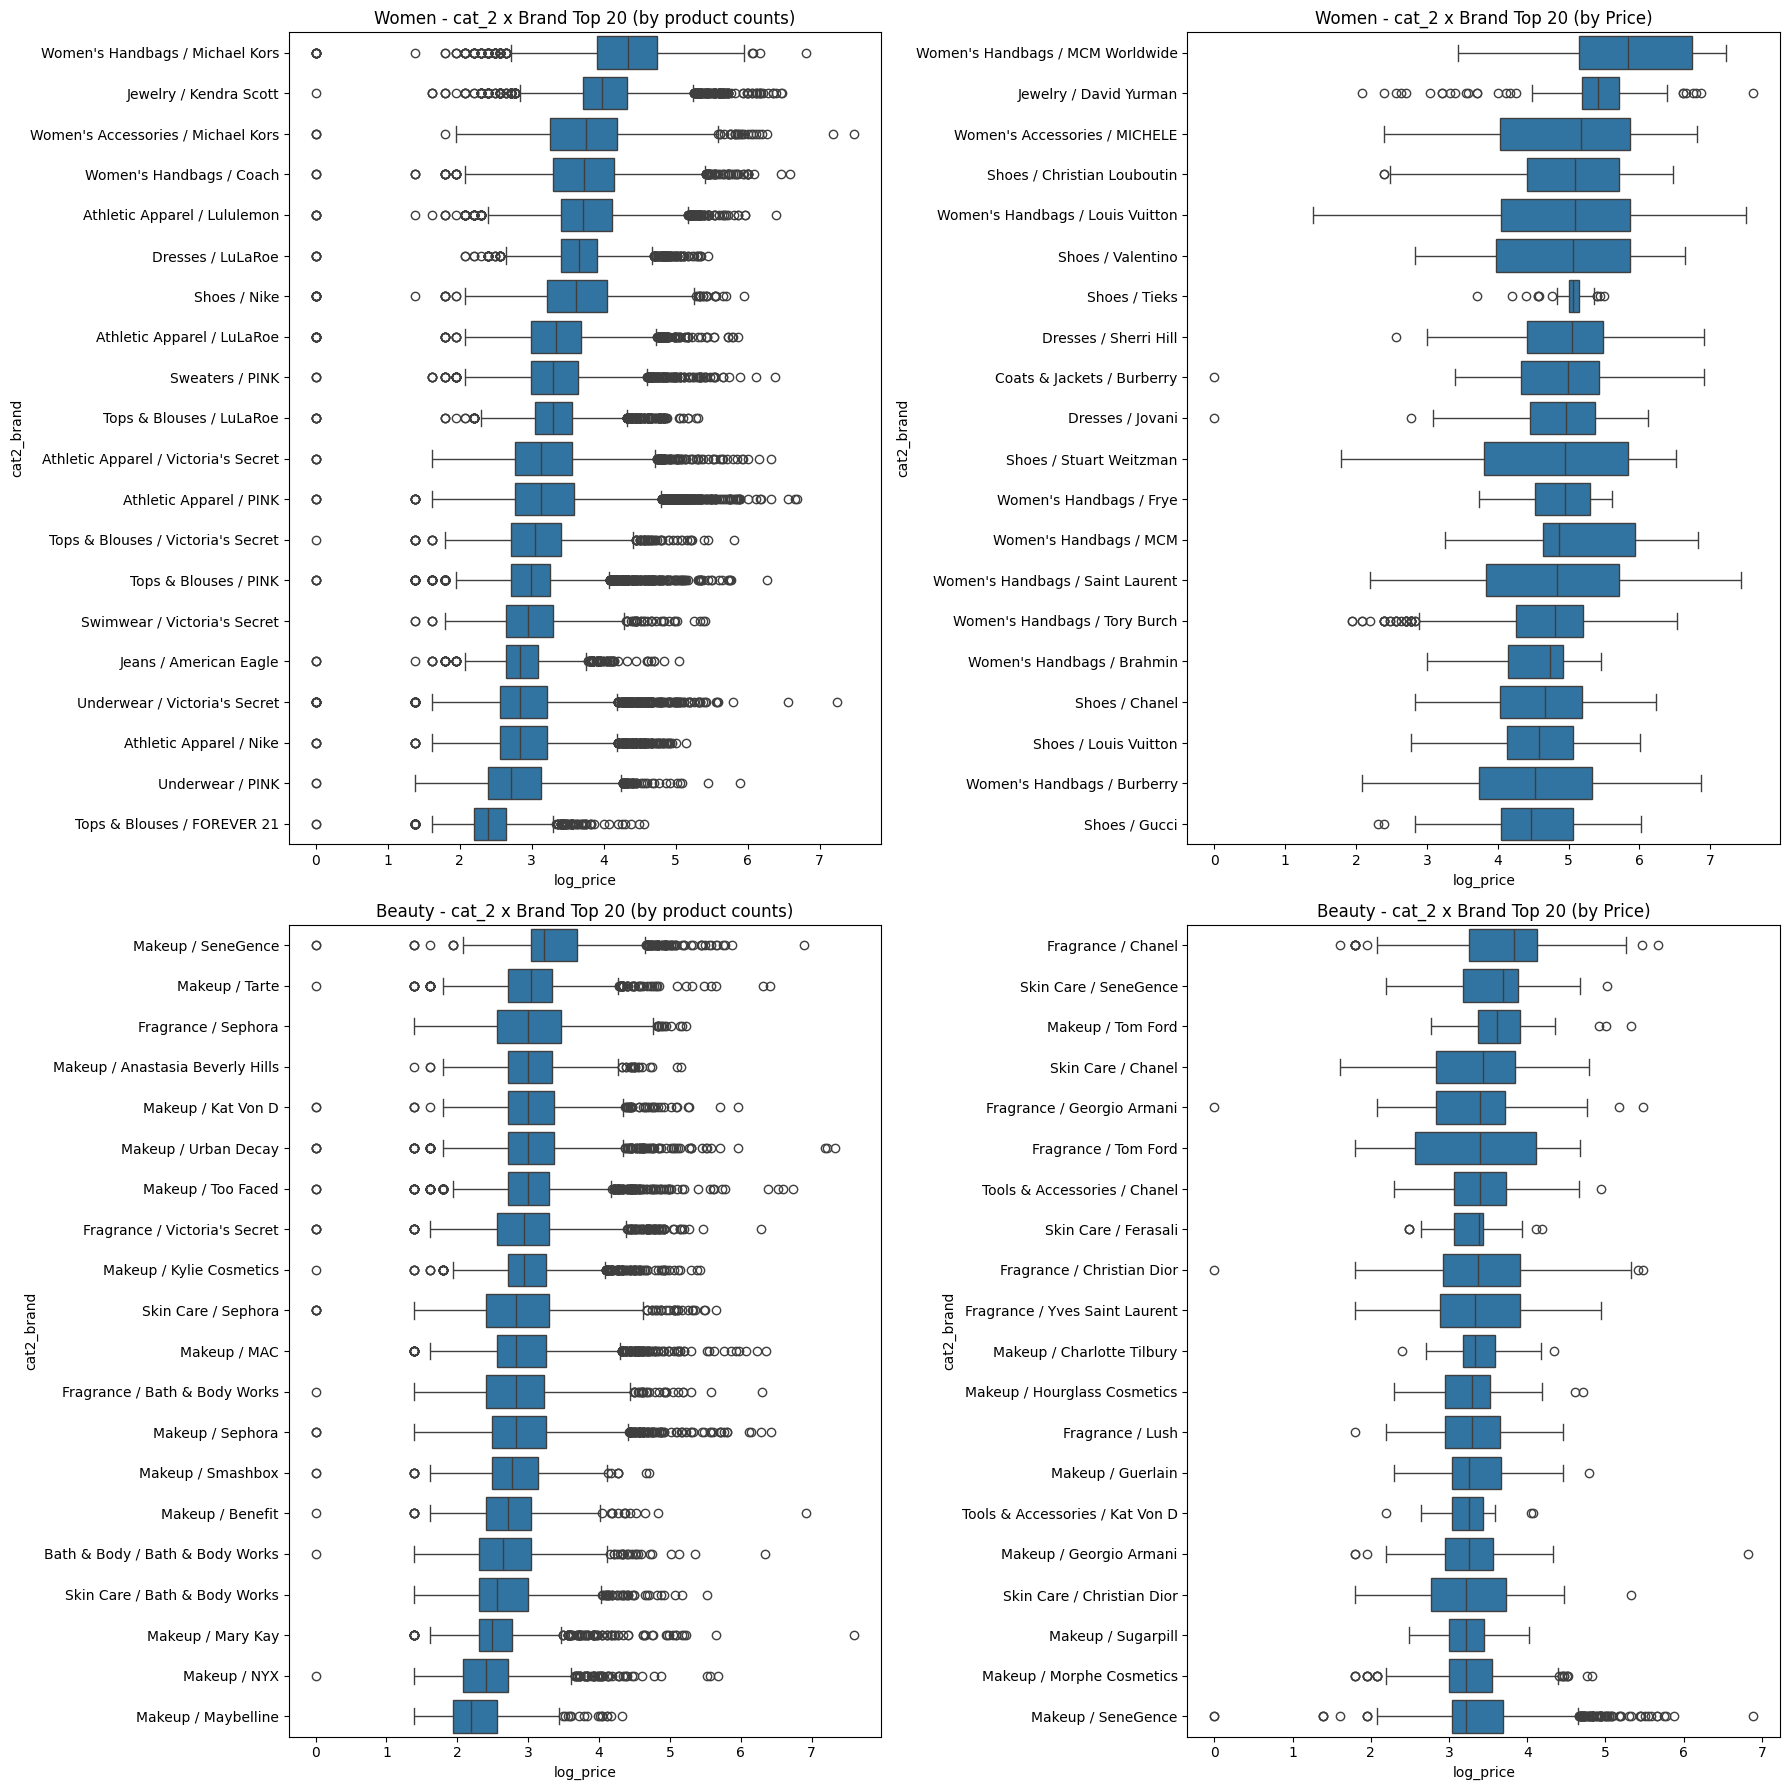

In [230]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

# Women 상품 수 기준 Top 20 조합 x log_price
sns.boxplot(y='cat2_brand', x='log_price',
            data=women_combo[women_combo['cat2_brand'].isin(women_combo_order)],
            order=women_combo[women_combo['cat2_brand'].isin(women_combo_order)]\
                .groupby('cat2_brand')['price'].median()\
                .sort_values(ascending=False).index,
            ax=axes[0][0])
axes[0][0].set_title('Women - cat_2 x Brand Top 20 (by product counts)')

# Women 가격 기준 Top 20 조합 x log_price
sns.boxplot(y='cat2_brand', x='log_price',
            data=women_valid[women_valid['cat2_brand'].isin(women_price_order)],
            order=women_price_order,
            ax=axes[0][1])
axes[0][1].set_title('Women - cat_2 x Brand Top 20 (by Price)')

# Beauty 상품 수 기준 Top 20 조합 x log_price
sns.boxplot(y='cat2_brand', x='log_price',
            data=beauty_combo[beauty_combo['cat2_brand'].isin(beauty_combo_order)],
            order=beauty_combo[beauty_combo['cat2_brand'].isin(beauty_combo_order)]\
                .groupby('cat2_brand')['price'].median()\
                .sort_values(ascending=False).index,
            ax=axes[1][0])
axes[1][0].set_title('Beauty - cat_2 x Brand Top 20 (by product counts)')

# Beauty 가격 기준 Top 20 조합 x log_price
sns.boxplot(y='cat2_brand', x='log_price',
            data=beauty_valid[beauty_valid['cat2_brand'].isin(beauty_price_order)],
            order=beauty_price_order,
            ax=axes[1][1])
axes[1][1].set_title('Beauty - cat_2 x Brand Top 20 (by Price)')

plt.tight_layout()
plt.show()

[중분류 카테고리와 브랜드 분석]

1. Women 카테고리 주요 조합:  
- 고가: Handbags x 럭셔리(MCM, Louis Vuitton, Tory Burch)
        Jewelry x 고가 브랜드(David Yurman, Kendra Scott)
        Shoes x 럭셔리(Christian Louboutin, Valentino)
- 저가: Tops & Blouses x 패스트패션(FOREVER 21, PINK)
        Underwear x PINK
        Athletic Apparel x Nike

2. Beauty 카테고리 주요 조합:
- 고가: Fragrance x 럭셔리(Chanel, Tom Ford, Giorgio Armani)
        Skin Care x 프리미엄(SeneGence, Chanel)
- 저가: Makeup x 대중(Maybelline, NYX, Mary Kay)
